In [1]:
# ================================================================================
# PARTE 1: INSTALAÇÃO E IMPORTAÇÕES
# ================================================================================
# Implementação do Paper:
# "Optimization-Based Operation of Distribution Grids With Residential Battery
#  Storage: Assessing Utility and Customer Benefits"
# IEEE Transactions on Power Systems, Vol. 38, No. 1, January 2023
# ================================================================================

# --- Instalação de Bibliotecas ---
# Instala a biblioteca `cvxpy`, que é uma ferramenta para modelagem e solução de problemas de otimização convexa.
# O argumento `-q` é usado para suprimir a saída detalhada da instalação.
!pip install cvxpy -q

# --- Importação de Bibliotecas Essenciais ---
# numpy: Biblioteca fundamental para computação numérica com arrays e matrizes.
# pandas: Biblioteca para manipulação e análise de dados, especialmente com DataFrames.
# matplotlib.pyplot: Módulo para criar gráficos e visualizações de dados.
# cvxpy: Biblioteca para definir e resolver problemas de otimização.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp

# --- Configuração Global de Gráficos (Matplotlib) ---
# Define parâmetros padrão para todos os gráficos gerados com matplotlib.
# 'figure.figsize': Define o tamanho padrão das figuras (largura, altura).
# 'font.size': Define o tamanho da fonte padrão para o texto dos gráficos.
# 'axes.grid': Ativa as grades nos eixos dos gráficos.
# 'axes.axisbelow': Garante que as linhas da grade sejam desenhadas abaixo dos outros elementos do gráfico.
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True

# --- Verificação de Solvers de Otimização ---
# Imprime uma seção para indicar o início da configuração inicial e verifica quais 'solvers' ( resolvedores de problemas de otimização)
# estão instalados e disponíveis para uso com o CVXPY. Solvers são algoritmos que CVXPY usa para encontrar as soluções ótimas.
print("="*70)
print("PARTE 1: CONFIGURAÇÃO INICIAL")
print("="*70)
print(f"\n✓ Bibliotecas importadas com sucesso")
print(f"✓ Solvers disponíveis: {cp.installed_solvers()}")
print("\n" + "="*70)

PARTE 1: CONFIGURAÇÃO INICIAL

✓ Bibliotecas importadas com sucesso
✓ Solvers disponíveis: ['CLARABEL', 'CVXOPT', 'GLPK', 'GLPK_MI', 'HIGHS', 'OSQP', 'SCIPY', 'SCS']



In [3]:
#================================================================================
#PARTE 2: PARÂMETROS DO SISTEMA
#================================================================================
#Referência: Paper Seção IV (página 224)
#================================================================================

print("="*70)
print("PARTE 2: PARÂMETROS DO SISTEMA")
print("="*70)

# ==============================================================================
# PARÂMETROS TEMPORAIS
# ==============================================================================
DELTA = 5 / 60      # Intervalo de tempo: 5 minutos = 5/60 horas
T = 24              # Horizonte: 24 horas
K = int(T / DELTA)  # Número de amostras: 288

# Vetor de tempo [horas]
t = np.arange(K) * DELTA

print(f"\n⏱️  TEMPORAL:")
print(f"    Δ = 5 min = {DELTA:.4f} h")
print(f"    T = {T} h")
print(f"    K = {K} amostras")

# ==============================================================================
# PARÂMETROS DA BATERIA (Paper: página 224)
# "5 kW, 10 kWh residential battery"
# ==============================================================================
P_BAT_MAX = 5.0     # ū: Potência máxima de carga [kW]
P_BAT_MIN = -5.0    # -u: Potência máxima de descarga [kW]
E_BAT_MAX = 10.0    # s̄: Capacidade máxima [kWh]
E_BAT_MIN = 0.0     # Capacidade mínima [kWh]
SOC_0 = 2.0         # s₀: Estado de carga inicial [kWh]
SOC_F = 2.0         # sf: Estado de carga final [kWh]

print(f"\n🔋 BATERIA:")
print(f"    Potência: ±{P_BAT_MAX} kW")
print(f"    Capacidade: {E_BAT_MAX} kWh")
print(f"    SOC inicial/final: {SOC_0} kWh")

# ==============================================================================
# PARÂMETROS DO INVERSOR (Paper: página 224)
# "6 kVA inverter", "dispatchable reactive power limit is 3.3 kvar"
# ==============================================================================
S_INVERSOR = 6.0    # Potência aparente nominal [kVA]
Q_BAT_MAX = 3.3     # v̄: Potência reativa máxima [kvar]
Q_BAT_MIN = -3.3    # -v: Potência reativa mínima [kvar]

# IEEE 1547: Q máximo = 44% da potência nominal
Q_IEEE1547 = 0.44 * S_INVERSOR  # = 2.64 kvar

print(f"\n⚡ INVERSOR:")
print(f"    S nominal: {S_INVERSOR} kVA")
print(f"    Q máx (L-QP): ±{Q_BAT_MAX} kvar")
print(f"    Q máx (IEEE 1547): ±{Q_IEEE1547:.2f} kvar")

# ==============================================================================
# PARÂMETROS DA REDE (IEEE 13 Node Test Feeder)
# Paper: "R/X ratio of paths range from 0.32 to 0.58"
# ==============================================================================
R_LINHA = 0.10      # Rmm: Resistência equivalente [Ω]
X_LINHA = 0.25      # Xmm: Reatância equivalente [Ω]
V_NOM = 1.0         # Vr: Tensão nominal [p.u.]
V_BASE = 2400       # Tensão base linha-terra [V]

print(f"\n🔌 REDE:")
print(f"    R = {R_LINHA} Ω")
print(f"    X = {X_LINHA} Ω")
print(f"    R/X = {R_LINHA/X_LINHA:.2f}")
print(f"    V nominal = {V_NOM} p.u.")

# ==============================================================================
# PARÂMETROS DE OTIMIZAÇÃO (Paper: página 224)
# ==============================================================================
SIGMA = 0.005       # Peso para regulação de tensão (ajustado)

print(f"\n⚙️  OTIMIZAÇÃO:")
print(f"    σ = {SIGMA}")

# ==============================================================================
# FATOR DE POTÊNCIA (Paper: página 224)
# "mean load power factor of 0.86"
# ==============================================================================
PF = 0.86
TAN_PHI = np.tan(np.arccos(PF))

print(f"\n📐 FATOR DE POTÊNCIA:")
print(f"    PF = {PF}")
print(f"    tan(φ) = {TAN_PHI:.4f}")

print("\n" + "="*70)
print("✓ Parâmetros configurados com sucesso!")
print("="*70)


PARTE 2: PARÂMETROS DO SISTEMA

⏱️  TEMPORAL:
    Δ = 5 min = 0.0833 h
    T = 24 h
    K = 288 amostras

🔋 BATERIA:
    Potência: ±5.0 kW
    Capacidade: 10.0 kWh
    SOC inicial/final: 2.0 kWh

⚡ INVERSOR:
    S nominal: 6.0 kVA
    Q máx (L-QP): ±3.3 kvar
    Q máx (IEEE 1547): ±2.64 kvar

🔌 REDE:
    R = 0.1 Ω
    X = 0.25 Ω
    R/X = 0.40
    V nominal = 1.0 p.u.

⚙️  OTIMIZAÇÃO:
    σ = 0.005

📐 FATOR DE POTÊNCIA:
    PF = 0.86
    tan(φ) = 0.5934

✓ Parâmetros configurados com sucesso!


PARTE 3: PERFIS DE CARGA E PV

📊 CARGA ATIVA d(k):
    Mínimo: 0.46 kW
    Máximo: 1.54 kW
    Média:  0.76 kW

☀️  GERAÇÃO PV g(k):
    Mínimo: -2.03 kW (pico de geração)
    Máximo: -0.00 kW
    Pico:   2.03 kW às 12h

⚡ CARGA REATIVA e(k):
    Mínimo: 0.27 kvar
    Máximo: 0.92 kvar


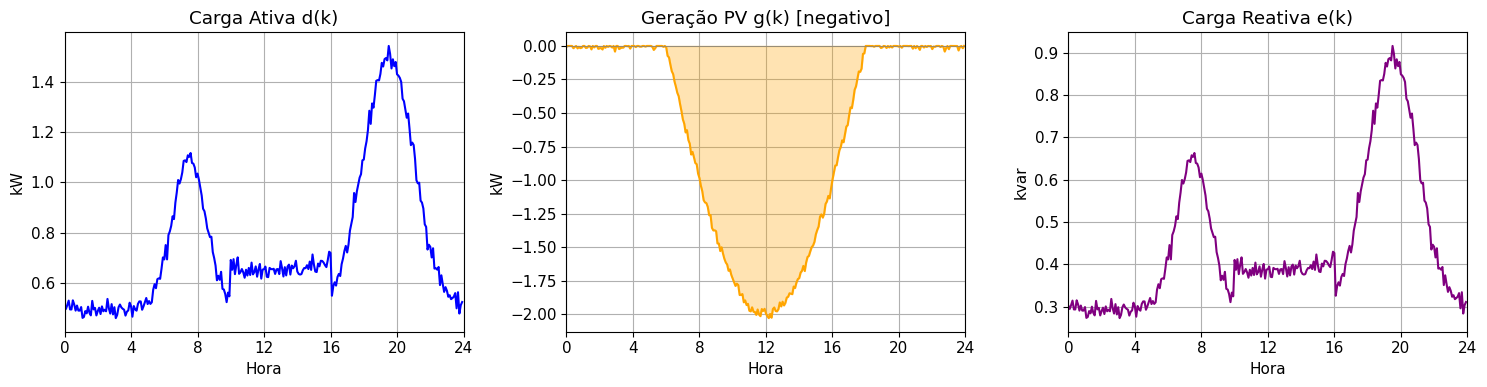


✓ Gráfico salvo: parte3_perfis.png


In [4]:

#================================================================================
#PARTE 3: PERFIS DE CARGA E GERAÇÃO PV
#================================================================================
#Referência: Paper Seção IV e Fig. 5 (página 225)
"""
Convenções do Paper (Equações 7 e 8):
- d(k) ≥ 0 : Carga ativa [kW] - sempre positiva
- g(k) ≤ 0 : Geração PV [kW] - sempre negativa (injeção)
- e(k) ≥ 0 : Carga reativa [kvar] - sempre positiva
================================================================================
"""

print("="*70)
print("PARTE 3: PERFIS DE CARGA E PV")
print("="*70)

# Semente para reprodutibilidade
np.random.seed(42)

# ==============================================================================
# CARGA ATIVA d(k) [kW]
# ==============================================================================
d_kw = np.zeros(K)

for k in range(K):
    hora = t[k]

    # Consumo base
    d_kw[k] = 0.5

    # Pico da manhã (café da manhã, banho)
    d_kw[k] += 0.6 * np.exp(-0.5 * ((hora - 7.5) / 1.0)**2)

    # Pico da noite (jantar, TV, etc.) - MAIOR
    d_kw[k] += 1.0 * np.exp(-0.5 * ((hora - 19.5) / 1.5)**2)

    # Atividade diurna leve
    if 10 <= hora <= 16:
        d_kw[k] += 0.15

# Adiciona pequeno ruído
d_kw += 0.02 * np.random.randn(K)
d_kw = np.clip(d_kw, 0.3, None)

print(f"\n📊 CARGA ATIVA d(k):")
print(f"    Mínimo: {d_kw.min():.2f} kW")
print(f"    Máximo: {d_kw.max():.2f} kW")
print(f"    Média:  {d_kw.mean():.2f} kW")

# ==============================================================================
# GERAÇÃO PV g(k) [kW] - NEGATIVA conforme convenção do Paper
# ==============================================================================
pv_magnitude = np.zeros(K)

for k in range(K):
    hora = t[k]

    # Geração solar: só durante o dia (6h às 18h)
    if 6 <= hora <= 18:
        pv_magnitude[k] = 2.0 * np.sin(np.pi * (hora - 6) / 12)

# Adiciona pequenas variações (nuvens)
pv_magnitude += 0.02 * np.random.randn(K)
pv_magnitude = np.clip(pv_magnitude, 0, 2.5)

# g(k) é NEGATIVO conforme convenção do Paper (Eq. 7)
g_kw = -pv_magnitude

print(f"\n☀️  GERAÇÃO PV g(k):")
print(f"    Mínimo: {g_kw.min():.2f} kW (pico de geração)")
print(f"    Máximo: {g_kw.max():.2f} kW")
print(f"    Pico:   {pv_magnitude.max():.2f} kW às 12h")

# ==============================================================================
# CARGA REATIVA e(k) [kvar]
# ==============================================================================
e_kvar = d_kw * TAN_PHI

print(f"\n⚡ CARGA REATIVA e(k):")
print(f"    Mínimo: {e_kvar.min():.2f} kvar")
print(f"    Máximo: {e_kvar.max():.2f} kvar")

# ==============================================================================
# VISUALIZAÇÃO
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(t, d_kw, 'b-', lw=1.5)
ax.set_xlabel('Hora')
ax.set_ylabel('kW')
ax.set_title('Carga Ativa d(k)')
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 4))

ax = axes[1]
ax.plot(t, g_kw, 'orange', lw=1.5)
ax.fill_between(t, g_kw, 0, alpha=0.3, color='orange')
ax.set_xlabel('Hora')
ax.set_ylabel('kW')
ax.set_title('Geração PV g(k) [negativo]')
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 4))
ax.axhline(0, color='gray', lw=0.5)

ax = axes[2]
ax.plot(t, e_kvar, 'purple', lw=1.5)
ax.set_xlabel('Hora')
ax.set_ylabel('kvar')
ax.set_title('Carga Reativa e(k)')
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 4))

plt.tight_layout()
plt.savefig('parte3_perfis.png', dpi=150)
plt.show()

print("\n✓ Gráfico salvo: parte3_perfis.png")
print("="*70)


PARTE 4: TARIFA TOU

💰 TARIFA TOU:
    Fora de ponta: $0.032/kWh (00h-07h, 22h-24h)
    Ponta:         $0.144/kWh (07h-09h, 17h-20h)
    Intermediário: $0.065/kWh (09h-17h, 20h-22h)


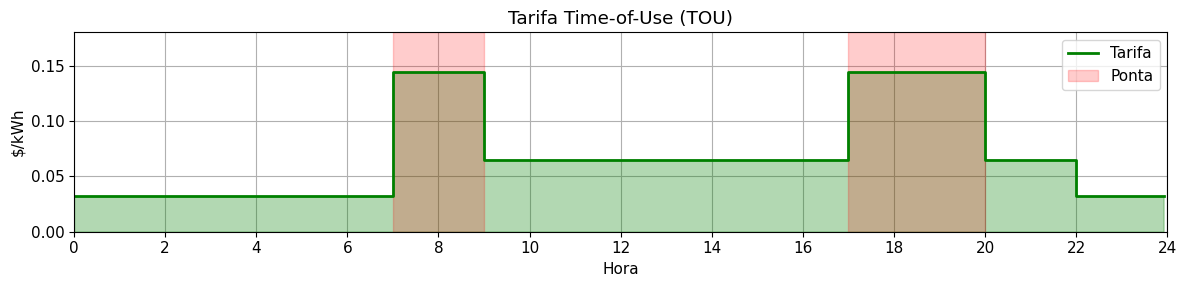


✓ Gráfico salvo: parte4_tarifa.png


In [5]:

# ================================================================================
# PARTE 4: TARIFA TIME-OF-USE (TOU)
# ================================================================================
# Referência: Paper Seção IV (página 224)
"""
Esta seção define a estrutura da tarifa de energia elétrica no modelo,
baseada em um esquema Time-of-Use (TOU). O preço da energia (η) varia ao longo
do dia, incentivando o consumo ou a injeção em determinados horários.

Detalhes da Tarifa publicada pelo distribuidor [40]:
- η = $0.032/kWh : 00h-07h e 22h-24h (fora de ponta - mais barato)
- η = $0.144/kWh : 07h-09h e 17h-20h (ponta - mais caro)
- η = $0.065/kWh : 09h-17h e 20h-22h (intermediário - preço médio)
================================================================================
"""

print("="*70)
print("PARTE 4: TARIFA TOU")
print("="*70)

# Inicializa vetor de tarifa
# Cria um array `eta` (preço da energia) com o mesmo número de amostras `K`,
# inicialmente preenchido com zeros. Este array armazenará o valor da tarifa
# para cada intervalo de tempo ao longo das 24 horas.
eta = np.zeros(K)

# Loop para definir a tarifa para cada intervalo de tempo
# Percorre todos os `K` intervalos de tempo para atribuir o valor da tarifa
# correspondente à hora atual, seguindo a lógica de Time-of-Use (TOU).
for k in range(K):
    hora = t[k] # Obtém a hora para o intervalo de tempo `k`

    # Fora de ponta: 00h-07h e 22h-24h
    # Nestes períodos, a tarifa é a mais baixa ($0.032/kWh).
    if hora < 7 or hora >= 22:
        eta[k] = 0.032

    # Ponta: 07h-09h e 17h-20h
    # Nestes períodos, a tarifa é a mais alta ($0.144/kWh), incentivando
    # a redução do consumo ou a injeção de energia (se possível).
    elif (7 <= hora < 9) or (17 <= hora < 20):
        eta[k] = 0.144

    # Intermediário: 09h-17h e 20h-22h
    # Nestes períodos, a tarifa tem um valor intermediário ($0.065/kWh).
    else:
        eta[k] = 0.065

# Peso para perdas = tarifa
# A variável `zeta` é utilizada no modelo como um coeficiente que penaliza
# as perdas na rede. Neste caso, ela é definida como uma cópia da tarifa `eta`,
# o que significa que o custo das perdas é diretamente proporcional ao preço da energia.
zeta = eta.copy()

print(f"\n💰 TARIFA TOU:")
print(f"    Fora de ponta: $0.032/kWh (00h-07h, 22h-24h)")
print(f"    Ponta:         $0.144/kWh (07h-09h, 17h-20h)")
print(f"    Intermediário: $0.065/kWh (09h-17h, 20h-22h)")

# Visualização da Tarifa TOU
# Cria um gráfico para ilustrar a variação da tarifa ao longo das 24 horas do dia.
fig, ax = plt.subplots(figsize=(12, 3))

# Plota a tarifa usando um gráfico em degraus ('step'), que é ideal para
# mostrar mudanças discretas e instantâneas nos valores.
ax.step(t, eta, 'g-', lw=2, where='post', label='Tarifa')
# Preenche a área abaixo da curva da tarifa para melhor visualização.
ax.fill_between(t, 0, eta, alpha=0.3, color='green', step='post')

# Marca períodos de ponta
# Adiciona retângulos sombreados para destacar visualmente os períodos de
# tarifa de ponta no gráfico, facilitando a identificação desses intervalos.
ax.axvspan(7, 9, alpha=0.2, color='red', label='Ponta')
ax.axvspan(17, 20, alpha=0.2, color='red')

# Configurações adicionais do gráfico
ax.set_xlabel('Hora') # Rótulo do eixo X
ax.set_ylabel('$/kWh') # Rótulo do eixo Y
ax.set_title('Tarifa Time-of-Use (TOU)') # Título do gráfico
ax.set_xlim(0, 24) # Limites do eixo X (de 0 a 24 horas)
ax.set_ylim(0, 0.18) # Limites do eixo Y (para a escala de tarifa)
ax.set_xticks(range(0, 25, 2)) # Define os 'ticks' do eixo X a cada 2 horas
ax.legend(loc='upper right') # Adiciona a legenda no canto superior direito

plt.tight_layout() # Ajusta automaticamente os parâmetros do subplot para que caibam na figura.
plt.savefig('parte4_tarifa.png', dpi=150) # Salva o gráfico como imagem PNG com alta resolução.
plt.show() # Exibe o gráfico.

print("\n✓ Gráfico salvo: parte4_tarifa.png")
print("="*70)

In [6]:
# ================================================================================
# PARTE 5: OTIMIZAÇÃO BENCHMARK
# ================================================================================
# Referência: Paper Seção III-D, Equação (33)

# Esta seção implementa o problema de otimização 'Benchmark', focado na minimização de custos.
# O controle da bateria é estritamente ativo, e a potência reativa é fixada por uma curva Volt-VAR.

# Benchmark:
# - Potência ATIVA u(k): otimizada para minimizar custo
# - Potência REATIVA v(k): curva Volt-VAR IEEE 1547 (v ≈ 0 no deadband)

# Problema:
#    min  Σ η(k) × p(k) × Δ
#    s.t. p(k) = d(k) + g(k) + u(k)
#         s(k+1) = s(k) + u(k) × Δ
#         -5 ≤ u(k) ≤ 5
#         0 ≤ s(k) ≤ 10
#         s(0) = s(K) = 2
# ================================================================================

print("="*70)
print("PARTE 5: OTIMIZAÇÃO BENCHMARK")
print("="*70)

# ==============================================================================
# VARIÁVEIS DE DECISÃO
# ==============================================================================
# u_bench: Variável de otimização para a potência ativa da bateria em cada instante de tempo (K).
#          Representa a carga (u > 0) ou descarga (u < 0) da bateria.
u_bench = cp.Variable(K, name='u_bench')
# s_bench: Variável de otimização para o estado de carga (SOC) da bateria em cada instante de tempo (K+1, incluindo o estado inicial).
s_bench = cp.Variable(K + 1, name='s_bench')

# ==============================================================================
# FUNÇÃO OBJETIVO: Minimizar custo de energia
# ==============================================================================
# p_liquida_bench: Potência líquida consumida da rede (carga + PV + bateria).
#                  d(k) = carga ativa (consumo)
#                  g(k) = geração PV (injeção, por isso negativa)
#                  u(k) = potência da bateria (carga/descarga)
p_liquida_bench = d_kw + g_kw + u_bench
# custo_energia: Soma do produto da tarifa (eta) pela potência líquida (p_liquida_bench) em cada intervalo, multiplicada pelo DELTA.
#                O objetivo é minimizar este custo total.
custo_energia = cp.sum(cp.multiply(eta, p_liquida_bench)) * DELTA

# Define o objetivo do problema como a minimização do custo total de energia.
objetivo_bench = cp.Minimize(custo_energia)

# ==============================================================================
# RESTRIÇÕES
# ==============================================================================
restricoes_bench = [
    # Estado de carga inicial e final da bateria devem ser iguais ao SOC_0 e SOC_F, respectivamente.
    s_bench[0] == SOC_0,
    s_bench[K] == SOC_F,

    # Limites de capacidade da bateria: o SOC deve estar entre E_BAT_MIN (0) e E_BAT_MAX (10 kWh).
    s_bench >= E_BAT_MIN,
    s_bench <= E_BAT_MAX,

    # Limites de potência da bateria: a potência de carga/descarga (u_bench) deve estar entre P_BAT_MIN (-5 kW) e P_BAT_MAX (5 kW).
    u_bench >= P_BAT_MIN,
    u_bench <= P_BAT_MAX,
]

# Dinâmica do SOC: s(k+1) = s(k) + u(k) × Δ
# Esta restrição modela a mudança no estado de carga da bateria ao longo do tempo.
# O SOC no próximo instante (k+1) é o SOC atual (k) mais a energia carregada/descarregada (u(k) * DELTA).
for k in range(K):
    restricoes_bench.append(s_bench[k + 1] == s_bench[k] + u_bench[k] * DELTA)

# ==============================================================================
# RESOLVE
# ==============================================================================
# Cria o problema de otimização com o objetivo e as restrições definidas.
problema_bench = cp.Problem(objetivo_bench, restricoes_bench)
# Resolve o problema de otimização utilizando um solver disponível.
problema_bench.solve()

print(f"\n🔧 SOLVER:")
print(f"    Status: {problema_bench.status}") # Exibe o status da solução (e.g., 'optimal', 'infeasible').
print(f"    Valor objetivo: {problema_bench.value:.4f}") # Exibe o valor mínimo do custo de energia.

# ==============================================================================
# EXTRAI RESULTADOS
# ==============================================================================
# Extrai os valores ótimos das variáveis de decisão.
u_benchmark = u_bench.value # Potência ativa da bateria otimizada.
s_benchmark = s_bench.value # Estado de carga da bateria otimizado.
p_benchmark = d_kw + g_kw + u_benchmark # Potência líquida da rede resultante.

# ==============================================================================
# POTÊNCIA REATIVA: IEEE 1547 (v ≈ 0 no deadband)
# ==============================================================================
# No problema benchmark, a potência reativa da bateria (v_benchmark) é considerada zero
# porque se assume que a tensão permanece próxima a 1.0 p.u., conforme a curva Volt-VAR IEEE 1547.
v_benchmark = np.zeros(K)

# Potência reativa líquida: Carga reativa (e_kvar) mais a potência reativa da bateria (que é zero).
q_benchmark = e_kvar + v_benchmark

# ==============================================================================
# RESULTADOS POR PERÍODO
# ==============================================================================
# Define índices para os diferentes períodos tarifários do dia.
idx_fora_ponta_1 = (t >= 0) & (t < 7)
idx_ponta_manha = (t >= 7) & (t < 9)
idx_intermediario = (t >= 9) & (t < 17)
idx_ponta_noite = (t >= 17) & (t < 20)
idx_fora_ponta_2 = (t >= 22)

print(f"\n📊 RESULTADOS BENCHMARK:")
print(f"    u(k): [{u_benchmark.min():.2f}, {u_benchmark.max():.2f}] kW") # Mínimo e máximo da potência ativa da bateria.
print(f"    v(k): [{v_benchmark.min():.2f}, {v_benchmark.max():.2f}] kvar (IEEE 1547)") # Mínimo e máximo da potência reativa da bateria.
print(f"    SOC:  [{s_benchmark.min():.2f}, {s_benchmark.max():.2f}] kWh") # Mínimo e máximo do estado de carga da bateria.

print(f"\n📊 u(k) POR PERÍODO:")
# Calcula a média da potência ativa da bateria em cada período tarifário, indicando se a bateria carrega ou descarrega.
print(f"    Fora ponta (0-7h):    {u_benchmark[idx_fora_ponta_1].mean():+.2f} kW → CARREGA")
print(f"    Ponta manhã (7-9h):   {u_benchmark[idx_ponta_manha].mean():+.2f} kW → DESCARREGA")
print(f"    Intermediário (9-17h):{u_benchmark[idx_intermediario].mean():+.2f} kW → CARREGA")
print(f"    Ponta noite (17-20h): {u_benchmark[idx_ponta_noite].mean():+.2f} kW → DESCARREGA")

# Custo total de energia sem a bateria (apenas carga e PV).
custo_sem_bateria = float(np.sum(eta * (d_kw + g_kw) * DELTA))
# Custo total de energia com a otimização da bateria (benchmark).
custo_benchmark = float(np.sum(eta * p_benchmark * DELTA))

print(f"\n💰 CUSTOS:")
print(f"    Sem bateria: ${custo_sem_bateria:.4f}") # Custo sem o uso da bateria.
print(f"    Benchmark:   ${custo_benchmark:.4f}") # Custo com a otimização benchmark da bateria.
print(f"    Economia:    ${custo_sem_bateria - custo_benchmark:.4f}") # Economia obtida com o benchmark.

print("\n✓ Otimização Benchmark concluída!")
print("="*70)

PARTE 5: OTIMIZAÇÃO BENCHMARK

🔧 SOLVER:
    Status: optimal
    Valor objetivo: -1.6190

📊 RESULTADOS BENCHMARK:
    u(k): [-5.00, 4.03] kW
    v(k): [0.00, 0.00] kvar (IEEE 1547)
    SOC:  [0.00, 10.00] kWh

📊 u(k) POR PERÍODO:
    Fora ponta (0-7h):    +1.14 kW → CARREGA
    Ponta manhã (7-9h):   -5.00 kW → DESCARREGA
    Intermediário (9-17h):+1.25 kW → CARREGA
    Ponta noite (17-20h): -3.33 kW → DESCARREGA

💰 CUSTOS:
    Sem bateria: $0.2910
    Benchmark:   $-1.6190
    Economia:    $1.9100

✓ Otimização Benchmark concluída!


In [7]:
#================================================================================
#PARTE 6: OTIMIZAÇÃO L-QP (MÉTODO PROPOSTO)
#================================================================================
#Referência: Paper Seção III-C, Equação (32)
"""
Esta seção implementa o problema de otimização Linear-Quadrático com Penalidade (L-QP),
proposto no paper. Diferente do Benchmark, o L-QP otimiza conjuntamente as potências
ativa e reativa da bateria, adicionando um termo de penalidade à função objetivo
para regular os desvios de tensão na rede.

Objetivo principal:
- Minimizar o custo de energia da residência.
- Minimizar os desvios de tensão na rede (introduzindo potência reativa).

Variáveis de controle:
- Potência ATIVA da bateria (u(k))
- Potência REATIVA da bateria (v(k))

Formulação do Problema L-QP:
    min  Σ [ η(k)×p(k)×Δ + σ×(Ẽ(k))²×Δ ]

Onde:
    η(k): Tarifa de energia no instante k
    p(k): Potência ativa líquida da rede (carga + PV + bateria)
    Δ: Intervalo de tempo
    σ: Coeficiente de peso para a regulação de tensão
    Ẽ(k): Desvio de tensão no instante k, calculado como 2×(Rmm×p(k) + Xmm×q(k)) [Eq. 21 do paper]
    q(k): Potência reativa líquida da rede (carga reativa + bateria reativa)

Restrições:
- Limites de potência ativa e reativa da bateria.
- Limites de estado de carga (SOC) da bateria.
- Dinâmica do SOC.
- Condição de SOC inicial e final.
================================================================================
"""

print("="*70)
print("PARTE 6: OTIMIZAÇÃO L-QP")
print("="*70)

# ==============================================================================
# VARIÁVEIS DE DECISÃO
# ==============================================================================
# u_lqp_var: Potência ativa da bateria (kW) em cada instante de tempo `K`.
#            Representa a carga (u_lqp_var > 0) ou descarga (u_lqp_var < 0).
u_lqp_var = cp.Variable(K, name='u_lqp')
# v_lqp_var: Potência reativa da bateria (kvar) em cada instante de tempo `K`.
#            Representa a injeção (v_lqp_var > 0) ou consumo (v_lqp_var < 0) de reativos.
v_lqp_var = cp.Variable(K, name='v_lqp')
# s_lqp_var: Estado de Carga (SOC) da bateria (kWh) em `K+1` instantes de tempo.
#            Inclui o SOC inicial e o SOC final.
s_lqp_var = cp.Variable(K + 1, name='s_lqp')

# ==============================================================================
# POTÊNCIAS LÍQUIDAS
# ==============================================================================
# p_liq: Potência ativa líquida na rede, resultado da soma da carga (d_kw),
#        geração PV (g_kw) e potência ativa da bateria (u_lqp_var).
p_liq = d_kw + g_kw + u_lqp_var
# q_liq: Potência reativa líquida na rede, resultado da soma da carga reativa (e_kvar)
#        e potência reativa da bateria (v_lqp_var).
q_liq = e_kvar + v_lqp_var

# ==============================================================================
# FUNÇÃO OBJETIVO (Eq. 32 simplificada do paper)
# ==============================================================================
# Termo 1: Custo de energia
# Representa o custo total de energia ativa comprada ou vendida da rede.
# É o somatório do produto da tarifa (eta) pela potência ativa líquida (p_liq),
# multiplicado pelo intervalo de tempo (DELTA).
termo_custo = cp.sum(cp.multiply(eta, p_liq)) * DELTA

# Termo 2: Regulação de tensão (Penalidade)
# Este termo penaliza os desvios de tensão na rede. É calculado usando a Eq. 21 do paper,
# que relaciona os desvios de tensão (E_tilde) com as potências ativa e reativa líquidas.
# O quadrado de E_tilde é somado e multiplicado pelo peso de regulação de tensão (SIGMA)
# e pelo intervalo de tempo (DELTA).
E_tilde = 2 * (R_LINHA * p_liq + X_LINHA * q_liq)
termo_tensao = SIGMA * cp.sum(cp.square(E_tilde)) * DELTA

# Objetivo total: Minimizar a soma do custo de energia e da penalidade por desvio de tensão.
objetivo_lqp = cp.Minimize(termo_custo + termo_tensao)

# ==============================================================================
# RESTRIÇÕES
# ==============================================================================
restricoes_lqp = [
    # Estado de carga inicial e final da bateria devem ser iguais ao SOC_0 e SOC_F, respectivamente.
    s_lqp_var[0] == SOC_0,
    s_lqp_var[K] == SOC_F,

    # Limites de capacidade da bateria: o SOC deve estar entre E_BAT_MIN (0 kWh) e E_BAT_MAX (10 kWh).
    s_lqp_var >= E_BAT_MIN,
    s_lqp_var <= E_BAT_MAX,

    # Limites de potência ativa da bateria: u_lqp_var deve estar entre P_BAT_MIN (-5 kW) e P_BAT_MAX (5 kW).
    u_lqp_var >= P_BAT_MIN,
    u_lqp_var <= P_BAT_MAX,

    # Limites de potência reativa da bateria: v_lqp_var deve estar entre Q_BAT_MIN (-3.3 kvar) e Q_BAT_MAX (3.3 kvar).
    v_lqp_var >= Q_BAT_MIN,
    v_lqp_var <= Q_BAT_MAX,
]

# Dinâmica do SOC: s(k+1) = s(k) + u(k) × Δ
# Esta restrição modela como o estado de carga da bateria evolui ao longo do tempo.
# O SOC no próximo instante (k+1) é o SOC atual (k) mais a energia carregada/descarregada (u_lqp_var[k] * DELTA).
for k in range(K):
    restricoes_lqp.append(s_lqp_var[k + 1] == s_lqp_var[k] + u_lqp_var[k] * DELTA)

# ==============================================================================
# RESOLVE
# ==============================================================================
# Cria o problema de otimização CVXPY com a função objetivo e as restrições definidas.
problema_lqp = cp.Problem(objetivo_lqp, restricoes_lqp)
# Resolve o problema de otimização usando um solver disponível (CVXPY escolhe o mais adequado).
problema_lqp.solve()

print(f"\n🔧 SOLVER:")
print(f"    Status: {problema_lqp.status}") # Exibe o status da solução (e.g., 'optimal', 'infeasible', 'optimal_inaccurate').
print(f"    Valor objetivo: {problema_lqp.value:.6f}") # Exibe o valor mínimo da função objetivo (custo + penalidade de tensão).

# ==============================================================================
# EXTRAI RESULTADOS
# ==============================================================================
# Extrai os valores ótimos das variáveis de decisão após a solução do problema.
u_lqp = u_lqp_var.value # Potência ativa da bateria otimizada.
v_lqp = v_lqp_var.value # Potência reativa da bateria otimizada.
s_lqp = s_lqp_var.value # Estado de carga da bateria otimizado.
p_lqp = d_kw + g_kw + u_lqp # Potência ativa líquida da rede resultante.
q_lqp = e_kvar + v_lqp # Potência reativa líquida da rede resultante.

# ==============================================================================
# RESULTADOS POR PERÍODO
# ==============================================================================
# Os índices de período tarifário (idx_fora_ponta_1, etc.) são reusados do Benchmark
# para analisar o comportamento da bateria L-QP em cada fase da tarifa.

print(f"\n📊 RESULTADOS L-QP:")
print(f"    u(k): [{u_lqp.min():.2f}, {u_lqp.max():.2f}] kW") # Mínimo e máximo da potência ativa da bateria.
print(f"    v(k): [{v_lqp.min():.2f}, {v_lqp.max():.2f}] kvar") # Mínimo e máximo da potência reativa da bateria.
print(f"    SOC:  [{s_lqp.min():.2f}, {s_lqp.max():.2f}] kWh") # Mínimo e máximo do estado de carga da bateria.

print(f"\n📊 u(k) POR PERÍODO:")
# Calcula a média da potência ativa da bateria em cada período tarifário.
print(f"    Fora ponta (0-7h):    {u_lqp[idx_fora_ponta_1].mean():+.2f} kW")
print(f"    Ponta manhã (7-9h):   {u_lqp[idx_ponta_manha].mean():+.2f} kW")
print(f"    Intermediário (9-17h):{u_lqp[idx_intermediario].mean():+.2f} kW")
print(f"    Ponta noite (17-20h): {u_lqp[idx_ponta_noite].mean():+.2f} kW")

# Custo total de energia da rede para o método L-QP (apenas o termo de custo, sem a penalidade de tensão).
custo_lqp = float(np.sum(eta * p_lqp * DELTA))

print(f"\n💰 CUSTOS:")
print(f"    Sem bateria: ${custo_sem_bateria:.4f}") # Custo sem o uso da bateria (reutilizado do benchmark).
print(f"    L-QP:        ${custo_lqp:.4f}") # Custo de energia com a otimização L-QP.
print(f"    Economia:    ${custo_sem_bateria - custo_lqp:.4f}") # Economia obtida com o L-QP em relação ao cenário sem bateria.

print("\n✓ Otimização L-QP concluída!")
print("="*70)

PARTE 6: OTIMIZAÇÃO L-QP

🔧 SOLVER:
    Status: optimal
    Valor objetivo: -1.619042

📊 RESULTADOS L-QP:
    u(k): [-5.00, 4.89] kW
    v(k): [-3.29, 1.83] kvar
    SOC:  [-0.00, 10.00] kWh

📊 u(k) POR PERÍODO:
    Fora ponta (0-7h):    +1.14 kW
    Ponta manhã (7-9h):   -5.00 kW
    Intermediário (9-17h):+1.25 kW
    Ponta noite (17-20h): -3.33 kW

💰 CUSTOS:
    Sem bateria: $0.2910
    L-QP:        $-1.6190
    Economia:    $1.9100

✓ Otimização L-QP concluída!


PARTE 7: GRÁFICOS


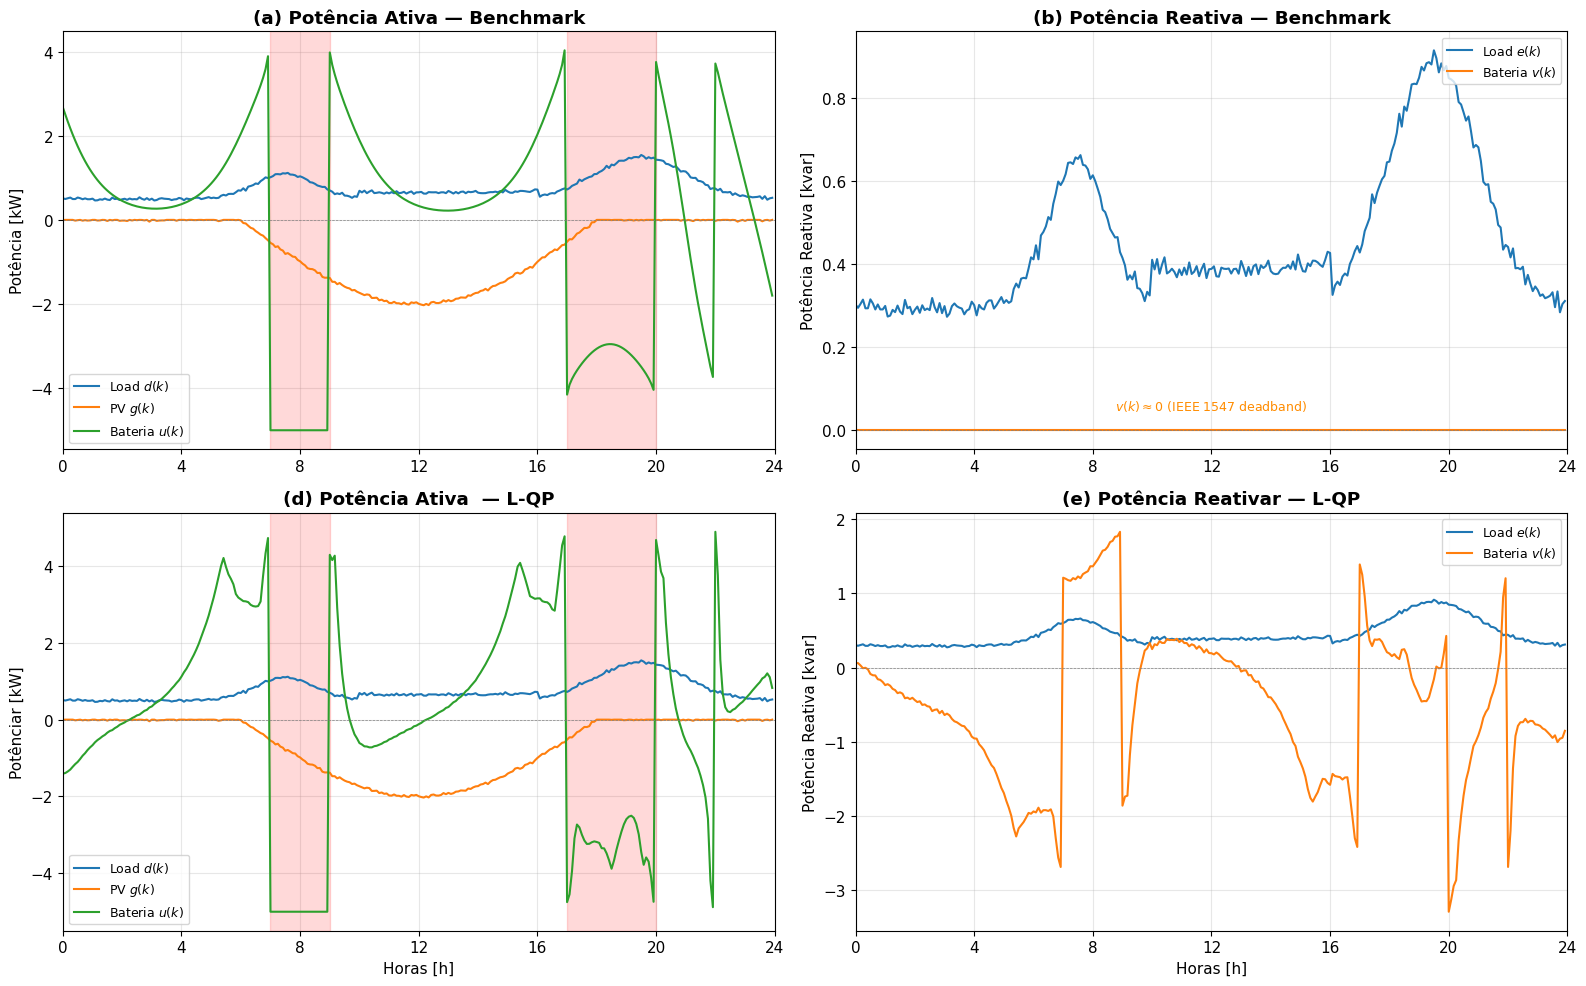


✓ Gráfico salvo: fig5_paper.png


In [8]:
"""
================================================================================
PARTE 7: GRÁFICOS - REPRODUÇÃO DA FIG. 5 DO PAPER
================================================================================
"""

print("="*70)
print("PARTE 7: GRÁFICOS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ==============================================================================
# LINHA 1: BENCHMARK
# ==============================================================================

# (a) Potência Real - Benchmark
ax = axes[0, 0]
ax.plot(t, d_kw, 'tab:blue', lw=1.5, label='Load $d(k)$')
ax.plot(t, g_kw, 'tab:orange', lw=1.5, label='PV $g(k)$')
ax.plot(t, u_benchmark, 'tab:green', lw=1.5, label='Bateria $u(k)$')
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvspan(7, 9, alpha=0.15, color='red')
ax.axvspan(17, 20, alpha=0.15, color='red')
ax.set_ylabel('Potência [kW]')
ax.set_title('(a) Potência Ativa — Benchmark', fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 4))
ax.grid(True, alpha=0.3)

# (b) Potência Reativa - Benchmark
ax = axes[0, 1]
ax.plot(t, e_kvar, 'tab:blue', lw=1.5, label='Load $e(k)$')
ax.plot(t, v_benchmark, 'tab:orange', lw=1.5, label='Bateria $v(k)$')
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.set_ylabel('Potência Reativa [kvar]')
ax.set_title('(b) Potência Reativa — Benchmark', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 4))
ax.grid(True, alpha=0.3)
ax.text(12, 0.05, '$v(k) \\approx 0$ (IEEE 1547 deadband)',
        ha='center', fontsize=9, color='darkorange')

# (c) SOC - Benchmark
"""
ax = axes[0, 2]
ax.plot(np.append(t, 24), s_benchmark, 'tab:green', lw=2)
ax.axhline(E_BAT_MAX, color='red', ls='--', alpha=0.7, label=f'Max = {E_BAT_MAX} kWh')
ax.axhline(E_BAT_MIN, color='blue', ls='--', alpha=0.7, label=f'Min = {E_BAT_MIN} kWh')
ax.fill_between(np.append(t, 24), 0, s_benchmark, alpha=0.3, color='green')
ax.axvspan(7, 9, alpha=0.15, color='red')
ax.axvspan(17, 20, alpha=0.15, color='red')
ax.set_ylabel('SOC [kWh]')
ax.set_title('(c) State of Charge — Benchmark', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 24)
ax.set_ylim(-0.5, 11)
ax.set_xticks(range(0, 25, 4))
ax.grid(True, alpha=0.3)
"""
# ==============================================================================
# LINHA 2: L-QP
# ==============================================================================

# (d) Potência Real - L-QP
ax = axes[1, 0]
ax.plot(t, d_kw, 'tab:blue', lw=1.5, label='Load $d(k)$')
ax.plot(t, g_kw, 'tab:orange', lw=1.5, label='PV $g(k)$')
ax.plot(t, u_lqp, 'tab:green', lw=1.5, label='Bateria $u(k)$')
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvspan(7, 9, alpha=0.15, color='red')
ax.axvspan(17, 20, alpha=0.15, color='red')
ax.set_xlabel('Horas [h]')
ax.set_ylabel('Potênciar [kW]')
ax.set_title('(d) Potência Ativa  — L-QP', fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 4))
ax.grid(True, alpha=0.3)

# (e) Potência Reativa - L-QP
ax = axes[1, 1]
ax.plot(t, e_kvar, 'tab:blue', lw=1.5, label='Load $e(k)$')
ax.plot(t, v_lqp, 'tab:orange', lw=1.5, label='Bateria $v(k)$')
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel('Horas [h]')
ax.set_ylabel('Potência Reativa [kvar]')
ax.set_title('(e) Potência Reativar — L-QP', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 4))
ax.grid(True, alpha=0.3)

# (f) SOC - L-QP
"""
ax = axes[1, 2]
ax.plot(np.append(t, 24), s_lqp, 'tab:green', lw=2)
ax.axhline(E_BAT_MAX, color='red', ls='--', alpha=0.7, label=f'Max = {E_BAT_MAX} kWh')
ax.axhline(E_BAT_MIN, color='blue', ls='--', alpha=0.7, label=f'Min = {E_BAT_MIN} kWh')
ax.fill_between(np.append(t, 24), 0, s_lqp, alpha=0.3, color='green')
ax.axvspan(7, 9, alpha=0.15, color='red')
ax.axvspan(17, 20, alpha=0.15, color='red')
ax.set_xlabel('Time [hour]')
ax.set_ylabel('SOC [kWh]')
ax.set_title('(f) State of Charge — L-QP', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 24)
ax.set_ylim(-0.5, 11)
ax.set_xticks(range(0, 25, 4))
ax.grid(True, alpha=0.3)
"""
plt.tight_layout()
plt.savefig('fig5_paper.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Gráfico salvo: fig5_paper.png")
print("="*70)


PARTE 8: COMPARAÇÃO E EXPORTAÇÃO

COMPARAÇÃO BENCHMARK vs L-QP

Métrica                           Benchmark         L-QP
------------------------------------------------------------
Custo energia ($)                   -1.6190      -1.6190
Economia vs sem bateria ($)          1.9100       1.9100
u(k) mínimo [kW]                      -5.00        -5.00
u(k) máximo [kW]                       4.03         4.89
v(k) mínimo [kvar]                     0.00        -3.29
v(k) máximo [kvar]                     0.00         1.83
SOC mínimo [kWh]                       0.00        -0.00
SOC máximo [kWh]                      10.00        10.00


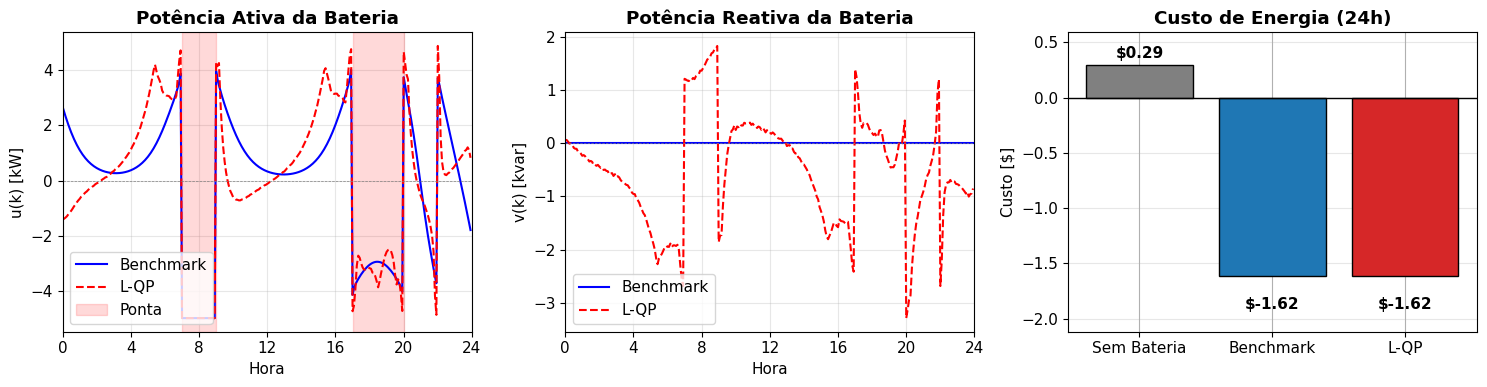


EXPORTAÇÃO DOS DADOS

📁 ARQUIVOS SALVOS:
    • resultados_completos.csv
    • bateria_lqp_opendss.csv
    • fig5_paper.png
    • comparacao_final.png

RESUMO FINAL - IMPLEMENTAÇÃO DO PAPER

┌─────────────────────────────────────────────────────────────────────┐
│                    RESULTADOS DA SIMULAÇÃO                          │
├─────────────────────────────────────────────────────────────────────┤
│  Cenário        │ Custo 24h │ Economia │ Benefício                  │
├─────────────────┼───────────┼──────────┼────────────────────────────┤
│  Sem bateria    │  $  0.29  │    -     │ Referência                 │
│  Benchmark      │  $ -1.62  │  $ 1.91  │ Máxima economia (cliente)  │
│  L-QP           │  $ -1.62  │  $ 1.91  │ Equilíbrio cliente+rede    │

├─────────────────────────────────────────────────────────────────────┤
│  NOTA: Custo negativo = RECEITA (arbitragem de tarifa)             │
└─────────────────────────────────────────────────────────────────────┘


✅ IMPLEMENTAÇÃO

In [9]:


#================================================================================
#PARTE 8: COMPARAÇÃO FINAL E EXPORTAÇÃO
#================================================================================
"""
Esta seção final consolida os resultados das otimizações Benchmark e L-QP,
apresentando uma comparação detalhada em formato de tabela e visualizações
gráficas. Além disso, os dados completos da simulação são exportados para
arquivos CSV, permitindo análises externas ou integração com outras ferramentas.
Finalmente, um resumo conciso dos principais achados é fornecido.
"""

print("="*70)
print("PARTE 8: COMPARAÇÃO E EXPORTAÇÃO")
print("="*70)

# ==============================================================================
# COMPARAÇÃO BENCHMARK vs L-QP
# ==============================================================================
# Esta subseção imprime uma tabela comparativa dos principais resultados
# obtidos pelas otimizações Benchmark e L-QP, focando em métricas como custo,
# limites de potência (ativa e reativa) e estado de carga da bateria.
print("\n" + "="*70)
print("COMPARAÇÃO BENCHMARK vs L-QP")
print("="*70)

# Formatação para impressão da tabela de resultados
print(f"\n{'Métrica':<30} {'Benchmark':>12} {'L-QP':>12}")
print("-"*60)
print(f"{'Custo energia ($)':<30} {custo_benchmark:>12.4f} {custo_lqp:>12.4f}")
print(f"{'Economia vs sem bateria ($)':<30} {custo_sem_bateria-custo_benchmark:>12.4f} {custo_sem_bateria-custo_lqp:>12.4f}")
print(f"{'u(k) mínimo [kW]':<30} {u_benchmark.min():>12.2f} {u_lqp.min():>12.2f}")
print(f"{'u(k) máximo [kW]':<30} {u_benchmark.max():>12.2f} {u_lqp.max():>12.2f}")
print(f"{'v(k) mínimo [kvar]':<30} {v_benchmark.min():>12.2f} {v_lqp.min():>12.2f}")
print(f"{'v(k) máximo [kvar]':<30} {v_benchmark.max():>12.2f} {v_lqp.max():>12.2f}")
print(f"{'SOC mínimo [kWh]':<30} {s_benchmark.min():>12.2f} {s_lqp.min():>12.2f}")
print(f"{'SOC máximo [kWh]':<30} {s_benchmark.max():>12.2f} {s_lqp.max():>12.2f}")

# ==============================================================================
# GRÁFICO DE COMPARAÇÃO
# ==============================================================================
# Cria uma figura com 1 linha e 3 colunas para os gráficos comparativos das
# potências ativa e reativa da bateria, e os custos totais de energia.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Potência Ativa da Bateria (u(k)) ---
# Este gráfico compara o perfil de potência ativa da bateria (carga/descarga)
# otimizado pelos métodos Benchmark e L-QP ao longo do dia. As áreas sombreadas
# indicam os períodos de ponta da tarifa.
ax = axes[0]
ax.plot(t, u_benchmark, 'b-', lw=1.5, label='Benchmark')
ax.plot(t, u_lqp, 'r--', lw=1.5, label='L-QP')
ax.axhline(0, color='gray', lw=0.5, ls='--') # Linha de referência em zero kW
ax.axvspan(7, 9, alpha=0.15, color='red', label='Ponta') # Período de ponta da manhã
ax.axvspan(17, 20, alpha=0.15, color='red') # Período de ponta da noite
ax.set_xlabel('Hora')
ax.set_ylabel('u(k) [kW]')
ax.set_title('Potência Ativa da Bateria', fontweight='bold')
ax.legend(loc='lower left')
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 4))
ax.grid(True, alpha=0.3)

# --- Potência Reativa da Bateria (v(k)) ---
# Este gráfico compara o perfil de potência reativa da bateria otimizado.
# Destaca-se que o Benchmark mantém v(k) em zero, enquanto o L-QP otimiza-o.
ax = axes[1]
ax.plot(t, v_benchmark, 'b-', lw=1.5, label='Benchmark')
ax.plot(t, v_lqp, 'r--', lw=1.5, label='L-QP')
ax.axhline(0, color='gray', lw=0.5, ls='--') # Linha de referência em zero kvar
ax.set_xlabel('Hora')
ax.set_ylabel('v(k) [kvar]')
ax.set_title('Potência Reativa da Bateria', fontweight='bold')
ax.legend(loc='lower left')
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 4))
ax.grid(True, alpha=0.3)

# --- Comparação de Custos ---
# Este gráfico de barras compara o custo total de energia para os três cenários:
# sem bateria, com otimização Benchmark e com otimização L-QP.
ax = axes[2]
categorias = ['Sem Bateria', 'Benchmark', 'L-QP']
custos = [custo_sem_bateria, custo_benchmark, custo_lqp]
cores = ['gray', 'tab:blue', 'tab:red']
bars = ax.bar(categorias, custos, color=cores, edgecolor='black')
ax.axhline(0, color='black', lw=1) # Linha de referência para custo zero
ax.set_ylabel('Custo [$]')
ax.set_title('Custo de Energia (24h)', fontweight='bold')

# Adiciona os valores de custo acima de cada barra para facilitar a leitura.
for bar, custo in zip(bars, custos):
    height = bar.get_height()
    ax.annotate(f'${custo:.2f}', # Formata o custo com duas casas decimais e símbolo de dólar
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -15), # Posição do texto (acima ou abaixo da barra)
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top',
                fontweight='bold')

ax.set_ylim(min(custos) - 0.5, max(custos) + 0.3) # Ajusta limites do eixo Y
ax.grid(True, alpha=0.3, axis='y') # Adiciona grade horizontal

plt.tight_layout() # Ajusta o layout para evitar sobreposição de elementos
plt.savefig('comparacao_final.png', dpi=150, bbox_inches='tight') # Salva o gráfico em alta resolução
plt.show() # Exibe o gráfico

# ==============================================================================
# EXPORTAÇÃO PARA CSV
# ==============================================================================
# Esta subseção exporta os dados completos da simulação e os resultados das
# potências da bateria L-QP para arquivos CSV, úteis para análises externas.
print("\n" + "="*70)
print("EXPORTAÇÃO DOS DADOS")
print("="*70)

# Cria um DataFrame Pandas combinando todos os dados relevantes da simulação:
# hora, minuto, tarifa, carga ativa/reativa, geração PV, e potências da bateria
# para os cenários Benchmark e L-QP.
df = pd.DataFrame({
    'hora': t,
    'minuto': (t * 60).astype(int),
    'tarifa_$/kWh': eta,
    'carga_P_kW': d_kw,
    'pv_P_kW': -g_kw, # Geração PV é salva como positiva para clareza no CSV
    'carga_Q_kvar': e_kvar,
    'bat_P_benchmark_kW': u_benchmark,
    'bat_Q_benchmark_kvar': v_benchmark,
    'bat_P_lqp_kW': u_lqp,
    'bat_Q_lqp_kvar': v_lqp,
})

# Salva o DataFrame completo em um arquivo CSV.
df.to_csv('resultados_completos.csv', index=False)

# Cria um DataFrame específico com as potências ativa e reativa da bateria
# otimizadas pelo método L-QP, em um formato adequado para ferramentas como OpenDSS.
df_opendss = pd.DataFrame({
    'hora': t,
    'P_kW': u_lqp,
    'Q_kvar': v_lqp,
})
# Salva este DataFrame em um arquivo CSV.
df_opendss.to_csv('bateria_lqp_opendss.csv', index=False)

print(f"\n📁 ARQUIVOS SALVOS:")
print(f"    • resultados_completos.csv")
print(f"    • bateria_lqp_opendss.csv")
print(f"    • fig5_paper.png") # Gráfico da Parte 7
print(f"    • comparacao_final.png") # Gráfico gerado nesta parte

# ==============================================================================
# RESUMO FINAL
# ==============================================================================
# Apresenta uma tabela textual resumindo os principais resultados financeiros
# e os benefícios de cada cenário de otimização.
print("\n" + "="*70)
print("RESUMO FINAL - IMPLEMENTAÇÃO DO PAPER")
print("="*70)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│                    RESULTADOS DA SIMULAÇÃO                          │
├─────────────────────────────────────────────────────────────────────┤
│  Cenário        │ Custo 24h │ Economia │ Benefício                  │
├─────────────────┼───────────┼──────────┼────────────────────────────┤""")
print(f"│  Sem bateria    │  ${custo_sem_bateria:>6.2f}  │    -     │ Referência                 │")
print(f"│  Benchmark      │  ${custo_benchmark:>6.2f}  │  ${custo_sem_bateria-custo_benchmark:>5.2f}  │ Máxima economia (cliente)  │")
print(f"│  L-QP           │  ${custo_lqp:>6.2f}  │  ${custo_sem_bateria-custo_lqp:>5.2f}  │ Equilíbrio cliente+rede    │")
print("""
├─────────────────────────────────────────────────────────────────────┤
│  NOTA: Custo negativo = RECEITA (arbitragem de tarifa)             │
└─────────────────────────────────────────────────────────────────────┘
""")

print("\n✅ IMPLEMENTAÇÃO CONCLUÍDA COM SUCESSO!")
print("="*70)

PARTE 9: Integração com OpenDSS

In [10]:

#================================================================================
#PARTE 9: CONFIGURAÇÃO DO OPENDSS (CORRIGIDO)
#================================================================================

print("="*70)
print("PARTE 9: VALIDAÇÃO COM OPENDSS")
print("="*70)

# Instala se necessário
try:
    import py_dss_interface
    print("✓ py-dss-interface já instalado")
except ImportError:
    print("Instalando py-dss-interface...")
    !pip install py-dss-interface -q
    import py_dss_interface
    print("✓ py-dss-interface instalado")

# Inicializa o DSS
dss = py_dss_interface.DSS()

# Verifica versão (sintaxe correta)
try:
    versao = dss.text("Get Version")
    print(f"\n✓ OpenDSS versão: {versao[:50]}...")
except:
    print("\n✓ OpenDSS inicializado (versão não disponível)")

print(f"✓ Interface Python inicializada")
print("="*70)


PARTE 9: VALIDAÇÃO COM OPENDSS
Instalando py-dss-interface...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 99.9 MB/s eta 0:00:00
✓ py-dss-interface instalado

✓ OpenDSS versão: You must create a new circuit object first: "new c...
✓ Interface Python inicializada


In [11]:

#================================================================================
#PARTE 9.1: VALIDAÇÃO MATEMÁTICA DO MODELO L-QP
#================================================================================



# Configuração de visualização
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True

print("="*70)
print("PARTE 9.1: VALIDAÇÃO MATEMÁTICA DO MODELO L-QP")
print("="*70)

# ==============================================================================
# PARÂMETROS DO SISTEMA
# ==============================================================================

# Tempo
DELTA = 0.25  # Intervalo de tempo [h] (15 min)
K = 96        # Número de intervalos (24h)
t = np.arange(K) * DELTA  # Vetor de tempo [h]

# Bateria
P_BAT_MAX = 5.0    # Potência máxima de carga [kW]
P_BAT_MIN = -5.0   # Potência máxima de descarga [kW]
E_BAT_MAX = 10.0   # Capacidade máxima [kWh]
E_BAT_MIN = 0.0    # Capacidade mínima [kWh]
SOC_0 = 2.0        # SOC inicial [kWh]
SOC_F = 2.0        # SOC final [kWh]

# Inversor - Potência Reativa
S_INV = 6.0        # Potência aparente do inversor [kVA]
Q_BAT_MAX = 3.3    # Limite de potência reativa [kvar]
Q_BAT_MIN = -3.3   # Limite de potência reativa [kvar]

# Rede
V_NOM = 1.0        # Tensão nominal [p.u.]
R_LINHA = 0.1      # Resistência da linha [Ω]
X_LINHA = 0.2      # Reatância da linha [Ω]

# Fator de potência da carga
FP_CARGA = 0.92
TAN_PHI = np.tan(np.arccos(FP_CARGA))

# Peso da regulação de tensão
SIGMA = 0.01

print(f"""
📋 PARÂMETROS DO SISTEMA:
{'─'*50}
⏱️  Tempo:
    • Δt = {DELTA} h ({int(DELTA*60)} min)
    • Horizonte = {K} intervalos ({K*DELTA:.0f} h)

🔋 Bateria:
    • Potência: [{P_BAT_MIN}, {P_BAT_MAX}] kW
    • Capacidade: [{E_BAT_MIN}, {E_BAT_MAX}] kWh
    • SOC inicial/final: {SOC_0}/{SOC_F} kWh

⚡ Inversor:
    • S_inv = {S_INV} kVA
    • Q: [{Q_BAT_MIN}, {Q_BAT_MAX}] kvar

🔌 Rede:
    • V_nom = {V_NOM} p.u.
    • R = {R_LINHA} Ω, X = {X_LINHA} Ω

📊 Outros:
    • tan(φ) = {TAN_PHI:.4f} (FP = {FP_CARGA})
    • σ = {SIGMA}
{'─'*50}
""")

# ==============================================================================
# TARIFA DE ENERGIA (TOU)
# ==============================================================================
eta = np.zeros(K)
for k in range(K):
    hora = t[k]
    if 17 <= hora < 21:      # Ponta (17h-21h)
        eta[k] = 0.60
    elif 7 <= hora < 17 or 21 <= hora < 23:  # Intermediário
        eta[k] = 0.35
    else:                    # Fora-ponta
        eta[k] = 0.15

print("✓ Tarifa TOU configurada")

# ==============================================================================
# PERFIS DE CARGA E GERAÇÃO
# ==============================================================================

# Carga ativa [kW]
d_kw = np.zeros(K)
for k in range(K):
    hora = t[k]
    d_kw[k] = 0.5  # Base
    d_kw[k] += 0.6 * np.exp(-0.5 * ((hora - 7.5) / 1.0)**2)   # Pico manhã
    d_kw[k] += 1.0 * np.exp(-0.5 * ((hora - 19.5) / 1.5)**2)  # Pico noite
    if 10 <= hora <= 16:
        d_kw[k] += 0.15

np.random.seed(42)
d_kw += 0.02 * np.random.randn(K)
d_kw = np.clip(d_kw, 0.2, None)

# Geração PV [kW] (negativa = injeção)
pv_kw = np.zeros(K)
for k in range(K):
    hora = t[k]
    if 6 <= hora <= 18:
        pv_kw[k] = 2.0 * np.sin(np.pi * (hora - 6) / 12)
pv_kw += 0.02 * np.random.randn(K)
pv_kw = np.clip(pv_kw, 0, 3.0)
g_kw = -pv_kw

# Carga reativa [kvar]
e_kvar = d_kw * TAN_PHI

print("✓ Perfis de carga e geração configurados")

# ==============================================================================
# CUSTO SEM BATERIA (REFERÊNCIA)
# ==============================================================================
p_liq_sem_bat = d_kw + g_kw
custo_sem_bateria = float(np.sum(eta * p_liq_sem_bat * DELTA))

print(f"\n📊 REFERÊNCIA:")
print(f"   Custo SEM bateria: ${custo_sem_bateria:.4f}/dia")

print("\n" + "="*70)
print("✓ PARTE 9.1 CONCLUÍDA - Sistema configurado!")
print("="*70)


PARTE 9.1: VALIDAÇÃO MATEMÁTICA DO MODELO L-QP

📋 PARÂMETROS DO SISTEMA:
──────────────────────────────────────────────────
⏱️  Tempo:
    • Δt = 0.25 h (15 min)
    • Horizonte = 96 intervalos (24 h)

🔋 Bateria:
    • Potência: [-5.0, 5.0] kW
    • Capacidade: [0.0, 10.0] kWh
    • SOC inicial/final: 2.0/2.0 kWh

⚡ Inversor:
    • S_inv = 6.0 kVA
    • Q: [-3.3, 3.3] kvar

🔌 Rede:
    • V_nom = 1.0 p.u.
    • R = 0.1 Ω, X = 0.2 Ω

📊 Outros:
    • tan(φ) = 0.4260 (FP = 0.92)
    • σ = 0.01
──────────────────────────────────────────────────

✓ Tarifa TOU configurada
✓ Perfis de carga e geração configurados

📊 REFERÊNCIA:
   Custo SEM bateria: $1.2780/dia

✓ PARTE 9.1 CONCLUÍDA - Sistema configurado!


In [12]:

#================================================================================
#PARTE 9.2: BENCHMARK (APENAS POTÊNCIA ATIVA)
#================================================================================


print("="*70)
print("PARTE 9.2: BENCHMARK (APENAS POTÊNCIA ATIVA)")
print("="*70)

# ==============================================================================
# VARIÁVEIS DE DECISÃO
# ==============================================================================
u_bench = cp.Variable(K)      # Potência ativa da bateria
s_bench = cp.Variable(K + 1)  # Estado de carga

# ==============================================================================
# FUNÇÃO OBJETIVO
# ==============================================================================
p_liq_bench = d_kw + g_kw + u_bench
objetivo_bench = cp.Minimize(cp.sum(cp.multiply(eta, p_liq_bench)) * DELTA)

# ==============================================================================
# RESTRIÇÕES
# ==============================================================================
restricoes_bench = [
    # SOC inicial e final
    s_bench[0] == SOC_0,
    s_bench[K] == SOC_F,

    # Limites de SOC
    s_bench >= E_BAT_MIN,
    s_bench <= E_BAT_MAX,

    # Limites de potência
    u_bench >= P_BAT_MIN,
    u_bench <= P_BAT_MAX,
]

# Dinâmica do SOC
for k in range(K):
    restricoes_bench.append(s_bench[k + 1] == s_bench[k] + u_bench[k] * DELTA)

# ==============================================================================
# RESOLVE
# ==============================================================================
prob_bench = cp.Problem(objetivo_bench, restricoes_bench)
prob_bench.solve(solver=cp.OSQP)

# Extrai soluções
u_benchmark = u_bench.value
s_benchmark = s_bench.value

# Calcula métricas
p_liq_benchmark = d_kw + g_kw + u_benchmark
custo_benchmark = float(np.sum(eta * p_liq_benchmark * DELTA))

# Tensão (modelo linearizado) - v=0 no benchmark
E_tilde_bench = 2 * (R_LINHA * p_liq_benchmark + X_LINHA * e_kvar)
V_benchmark = V_NOM - E_tilde_bench / (2 * V_NOM)

print(f"""
📊 RESULTADOS BENCHMARK:
{'─'*50}
   Status: {prob_bench.status}
   Custo: ${custo_benchmark:.4f}/dia
   Economia vs sem bateria: ${custo_sem_bateria - custo_benchmark:.4f}/dia

   Tensão:
   • V_min: {V_benchmark.min():.4f} p.u.
   • V_max: {V_benchmark.max():.4f} p.u.
   • Range: {(V_benchmark.max() - V_benchmark.min())*100:.2f}%
{'─'*50}
""")

print("="*70)
print("✓ PARTE 9.2 CONCLUÍDA - Benchmark calculado!")
print("="*70)


PARTE 9.2: BENCHMARK (APENAS POTÊNCIA ATIVA)

📊 RESULTADOS BENCHMARK:
──────────────────────────────────────────────────
   Status: optimal
   Custo: $-3.2220/dia
   Economia vs sem bateria: $4.5000/dia

   Tensão:
   • V_min: 0.3731 p.u.
   • V_max: 1.3977 p.u.
   • Range: 102.46%
──────────────────────────────────────────────────

✓ PARTE 9.2 CONCLUÍDA - Benchmark calculado!


In [13]:

#================================================================================
#PARTE 9.3: L-QP (POTÊNCIA ATIVA + REATIVA)
#================================================================================


print("="*70)
print("PARTE 9.3: L-QP (POTÊNCIA ATIVA + REATIVA)")
print("="*70)

# ==============================================================================
# VARIÁVEIS DE DECISÃO
# ==============================================================================
u_lqp = cp.Variable(K)      # Potência ativa da bateria
v_lqp = cp.Variable(K)      # Potência reativa da bateria
s_lqp = cp.Variable(K + 1)  # Estado de carga

# ==============================================================================
# FUNÇÃO OBJETIVO
# ==============================================================================
p_liq_lqp_var = d_kw + g_kw + u_lqp
q_liq_lqp_var = e_kvar + v_lqp

# Termo 1: Custo de energia
termo_custo = cp.sum(cp.multiply(eta, p_liq_lqp_var)) * DELTA

# Termo 2: Penalização de tensão
E_tilde_lqp_var = 2 * (R_LINHA * p_liq_lqp_var + X_LINHA * q_liq_lqp_var)
termo_tensao = SIGMA * cp.sum(cp.square(E_tilde_lqp_var)) * DELTA

objetivo_lqp = cp.Minimize(termo_custo + termo_tensao)

# ==============================================================================
# RESTRIÇÕES
# ==============================================================================
restricoes_lqp = [
    # SOC inicial e final
    s_lqp[0] == SOC_0,
    s_lqp[K] == SOC_F,

    # Limites de SOC
    s_lqp >= E_BAT_MIN,
    s_lqp <= E_BAT_MAX,

    # Limites de potência ativa
    u_lqp >= P_BAT_MIN,
    u_lqp <= P_BAT_MAX,

    # Limites de potência reativa
    v_lqp >= Q_BAT_MIN,
    v_lqp <= Q_BAT_MAX,
]

# Dinâmica do SOC
for k in range(K):
    restricoes_lqp.append(s_lqp[k + 1] == s_lqp[k] + u_lqp[k] * DELTA)

# ==============================================================================
# RESOLVE
# ==============================================================================
prob_lqp = cp.Problem(objetivo_lqp, restricoes_lqp)
prob_lqp.solve(solver=cp.OSQP)

# Extrai soluções
u_lqp_sol = u_lqp.value
v_lqp_sol = v_lqp.value
s_lqp_sol = s_lqp.value

# Calcula métricas
p_liq_lqp = d_kw + g_kw + u_lqp_sol
q_liq_lqp = e_kvar + v_lqp_sol
custo_lqp = float(np.sum(eta * p_liq_lqp * DELTA))

# Tensão (modelo linearizado)
E_tilde_lqp = 2 * (R_LINHA * p_liq_lqp + X_LINHA * q_liq_lqp)
V_lqp = V_NOM - E_tilde_lqp / (2 * V_NOM)

print(f"""
📊 RESULTADOS L-QP:
{'─'*50}
   Status: {prob_lqp.status}
   Custo: ${custo_lqp:.4f}/dia
   Economia vs sem bateria: ${custo_sem_bateria - custo_lqp:.4f}/dia

   Tensão:
   • V_min: {V_lqp.min():.4f} p.u.
   • V_max: {V_lqp.max():.4f} p.u.
   • Range: {(V_lqp.max() - V_lqp.min())*100:.2f}%

   Potência Reativa:
   • v_min: {v_lqp_sol.min():.2f} kvar
   • v_max: {v_lqp_sol.max():.2f} kvar
   • |v|_max: {np.abs(v_lqp_sol).max():.2f} kvar
{'─'*50}
""")

print("="*70)
print("✓ PARTE 9.3 CONCLUÍDA - L-QP calculado!")
print("="*70)


PARTE 9.3: L-QP (POTÊNCIA ATIVA + REATIVA)

📊 RESULTADOS L-QP:
──────────────────────────────────────────────────
   Status: optimal
   Custo: $-3.2220/dia
   Economia vs sem bateria: $4.5000/dia

   Tensão:
   • V_min: 1.0000 p.u.
   • V_max: 1.0000 p.u.
   • Range: 0.00%

   Potência Reativa:
   • v_min: -2.89 kvar
   • v_max: 1.86 kvar
   • |v|_max: 2.89 kvar
──────────────────────────────────────────────────

✓ PARTE 9.3 CONCLUÍDA - L-QP calculado!


In [14]:
"""
================================================================================
PARTE 9.4: COMPARAÇÃO BENCHMARK vs L-QP
================================================================================
"""

print("="*70)
print("PARTE 9.4: COMPARAÇÃO BENCHMARK vs L-QP")
print("="*70)

# Tensão sem bateria
p_liq_sem = d_kw + g_kw
E_tilde_sem = 2 * (R_LINHA * p_liq_sem + X_LINHA * e_kvar)
V_sem_bat = V_NOM - E_tilde_sem / (2 * V_NOM)

# Tabela comparativa
print(f"""
┌───────────────────────────────────────────────────────────────────────┐
│                   COMPARAÇÃO DOS CENÁRIOS                             │
├──────────────────┬──────────────┬──────────────┬──────────────────────┤
│     Métrica      │  Sem Bateria │   Benchmark  │        L-QP          │
├──────────────────┼──────────────┼──────────────┼──────────────────────┤
│ Custo [$/dia]    │    {custo_sem_bateria:>7.4f}   │    {custo_benchmark:>7.4f}   │       {custo_lqp:>7.4f}        │
│ Economia [$/dia] │       -      │    {custo_sem_bateria - custo_benchmark:>7.4f}   │       {custo_sem_bateria - custo_lqp:>7.4f}        │
│ V_min [p.u.]     │    {V_sem_bat.min():>7.4f}   │    {V_benchmark.min():>7.4f}   │       {V_lqp.min():>7.4f}        │
│ V_max [p.u.]     │    {V_sem_bat.max():>7.4f}   │    {V_benchmark.max():>7.4f}   │       {V_lqp.max():>7.4f}        │
│ Range V [%]      │    {(V_sem_bat.max()-V_sem_bat.min())*100:>7.2f}   │    {(V_benchmark.max()-V_benchmark.min())*100:>7.2f}   │       {(V_lqp.max()-V_lqp.min())*100:>7.2f}        │
│ |v|_max [kvar]   │       -      │       0      │       {np.abs(v_lqp_sol).max():>7.2f}        │
└──────────────────┴──────────────┴──────────────┴──────────────────────┘
""")

# Melhoria percentual
melhoria_tensao = ((V_benchmark.max() - V_benchmark.min()) - (V_lqp.max() - V_lqp.min())) / (V_benchmark.max() - V_benchmark.min()) * 100

print(f"""
📈 MELHORIAS DO L-QP vs BENCHMARK:
{'─'*50}
   • Redução do range de tensão: {melhoria_tensao:.1f}%
   • Diferença de custo: ${abs(custo_lqp - custo_benchmark):.4f}/dia
   • Potência reativa utilizada: {np.abs(v_lqp_sol).max():.2f} kvar
{'─'*50}
""")

print("="*70)
print("✓ PARTE 9.4 CONCLUÍDA!")
print("="*70)


PARTE 9.4: COMPARAÇÃO BENCHMARK vs L-QP

┌───────────────────────────────────────────────────────────────────────┐
│                   COMPARAÇÃO DOS CENÁRIOS                             │
├──────────────────┬──────────────┬──────────────┬──────────────────────┤
│     Métrica      │  Sem Bateria │   Benchmark  │        L-QP          │
├──────────────────┼──────────────┼──────────────┼──────────────────────┤
│ Custo [$/dia]    │     1.2780   │    -3.2220   │       -3.2220        │
│ Economia [$/dia] │       -      │     4.5000   │        4.5000        │
│ V_min [p.u.]     │     0.7224   │     0.3731   │        1.0000        │
│ V_max [p.u.]     │     1.0873   │     1.3977   │        1.0000        │
│ Range V [%]      │      36.49   │     102.46   │          0.00        │
│ |v|_max [kvar]   │       -      │       0      │          2.89        │
└──────────────────┴──────────────┴──────────────┴──────────────────────┘


📈 MELHORIAS DO L-QP vs BENCHMARK:
───────────────────────────────────

PARTE 9.5: GRÁFICOS DE VALIDAÇÃO


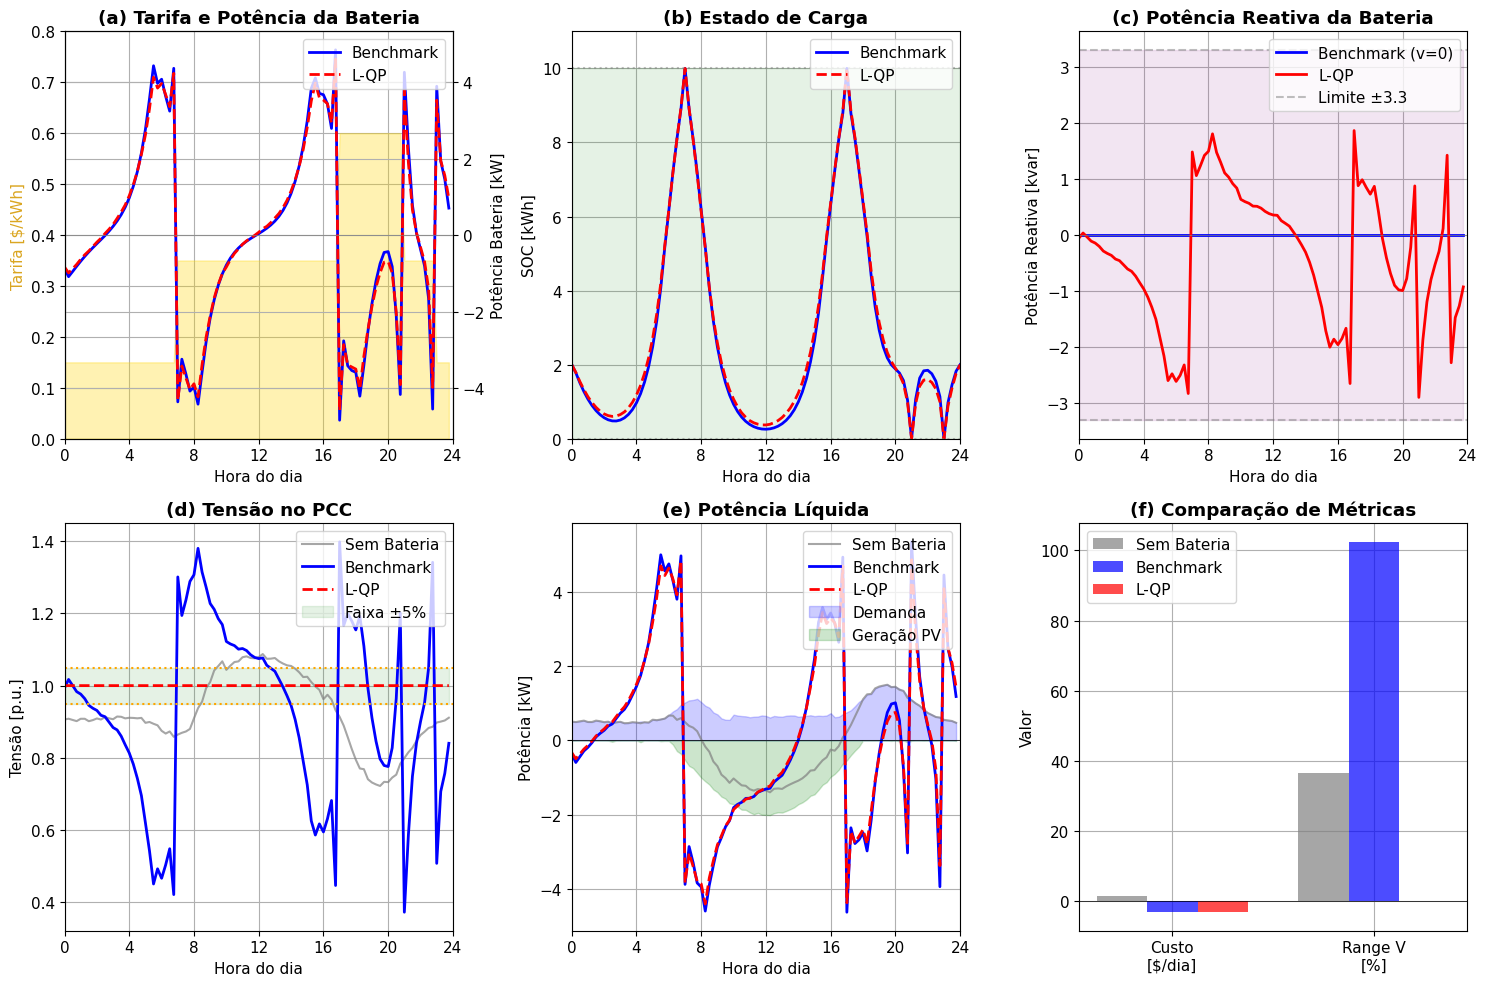


✓ Gráfico salvo: parte9_validacao_completa.png
✓ PARTE 9 CONCLUÍDA!


In [15]:
"""
================================================================================
PARTE 9.5: GRÁFICOS DE VALIDAÇÃO
================================================================================
"""

print("="*70)
print("PARTE 9.5: GRÁFICOS DE VALIDAÇÃO")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# ==============================================================================
# (a) Tarifa e Potência da Bateria
# ==============================================================================
ax = axes[0, 0]
ax2 = ax.twinx()

ax.fill_between(t, 0, eta, alpha=0.3, color='gold', label='Tarifa')
ax.set_ylabel('Tarifa [$/kWh]', color='goldenrod')
ax.set_ylim([0, 0.8])

ax2.plot(t, u_benchmark, 'b-', lw=2, label='Benchmark')
ax2.plot(t, u_lqp_sol, 'r--', lw=2, label='L-QP')
ax2.axhline(0, color='gray', ls='-', lw=0.5)
ax2.set_ylabel('Potência Bateria [kW]')

ax.set_xlabel('Hora do dia')
ax.set_title('(a) Tarifa e Potência da Bateria', fontweight='bold')
ax.set_xlim([0, 24])
ax.set_xticks(range(0, 25, 4))
ax2.legend(loc='upper right')

# ==============================================================================
# (b) Estado de Carga
# ==============================================================================
ax = axes[0, 1]
t_soc = np.arange(K + 1) * DELTA

ax.plot(t_soc, s_benchmark, 'b-', lw=2, label='Benchmark')
ax.plot(t_soc, s_lqp_sol, 'r--', lw=2, label='L-QP')
ax.axhline(E_BAT_MAX, color='gray', ls=':', alpha=0.5)
ax.axhline(E_BAT_MIN, color='gray', ls=':', alpha=0.5)

ax.fill_between(t_soc, E_BAT_MIN, E_BAT_MAX, alpha=0.1, color='green')
ax.set_xlabel('Hora do dia')
ax.set_ylabel('SOC [kWh]')
ax.set_title('(b) Estado de Carga', fontweight='bold')
ax.set_xlim([0, 24])
ax.set_ylim([0, E_BAT_MAX * 1.1])
ax.set_xticks(range(0, 25, 4))
ax.legend(loc='upper right')

# ==============================================================================
# (c) Potência Reativa
# ==============================================================================
ax = axes[0, 2]
ax.plot(t, np.zeros(K), 'b-', lw=2, label='Benchmark (v=0)')
ax.plot(t, v_lqp_sol, 'r-', lw=2, label='L-QP')
ax.axhline(Q_BAT_MAX, color='gray', ls='--', alpha=0.5, label=f'Limite ±{Q_BAT_MAX}')
ax.axhline(Q_BAT_MIN, color='gray', ls='--', alpha=0.5)
ax.axhline(0, color='gray', ls='-', lw=0.5)

ax.fill_between(t, Q_BAT_MIN, Q_BAT_MAX, alpha=0.1, color='purple')
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Potência Reativa [kvar]')
ax.set_title('(c) Potência Reativa da Bateria', fontweight='bold')
ax.set_xlim([0, 24])
ax.set_xticks(range(0, 25, 4))
ax.legend(loc='upper right')

# ==============================================================================
# (d) Tensão no PCC
# ==============================================================================
ax = axes[1, 0]
ax.plot(t, V_sem_bat, 'gray', lw=1.5, alpha=0.7, label='Sem Bateria')
ax.plot(t, V_benchmark, 'b-', lw=2, label='Benchmark')
ax.plot(t, V_lqp, 'r--', lw=2, label='L-QP')

ax.axhline(1.05, color='orange', ls=':', lw=1.5)
ax.axhline(0.95, color='orange', ls=':', lw=1.5)
ax.fill_between(t, 0.95, 1.05, alpha=0.1, color='green', label='Faixa ±5%')

ax.set_xlabel('Hora do dia')
ax.set_ylabel('Tensão [p.u.]')
ax.set_title('(d) Tensão no PCC', fontweight='bold')
ax.set_xlim([0, 24])
ax.set_xticks(range(0, 25, 4))
ax.legend(loc='upper right')

# ==============================================================================
# (e) Potência Líquida
# ==============================================================================
ax = axes[1, 1]
ax.plot(t, p_liq_sem, 'gray', lw=1.5, alpha=0.7, label='Sem Bateria')
ax.plot(t, p_liq_benchmark, 'b-', lw=2, label='Benchmark')
ax.plot(t, p_liq_lqp, 'r--', lw=2, label='L-QP')
ax.axhline(0, color='black', ls='-', lw=0.5)

ax.fill_between(t, 0, d_kw, alpha=0.2, color='blue', label='Demanda')
ax.fill_between(t, 0, g_kw, alpha=0.2, color='green', label='Geração PV')

ax.set_xlabel('Hora do dia')
ax.set_ylabel('Potência [kW]')
ax.set_title('(e) Potência Líquida', fontweight='bold')
ax.set_xlim([0, 24])
ax.set_xticks(range(0, 25, 4))
ax.legend(loc='upper right')

# ==============================================================================
# (f) Comparação de Métricas (Barras)
# ==============================================================================
ax = axes[1, 2]

metricas = ['Custo\n[$/dia]', 'Range V\n[%]']
x = np.arange(len(metricas))
width = 0.25

valores_sem = [custo_sem_bateria, (V_sem_bat.max() - V_sem_bat.min()) * 100]
valores_bench = [custo_benchmark, (V_benchmark.max() - V_benchmark.min()) * 100]
valores_lqp = [custo_lqp, (V_lqp.max() - V_lqp.min()) * 100]

bars1 = ax.bar(x - width, valores_sem, width, label='Sem Bateria', color='gray', alpha=0.7)
bars2 = ax.bar(x, valores_bench, width, label='Benchmark', color='blue', alpha=0.7)
bars3 = ax.bar(x + width, valores_lqp, width, label='L-QP', color='red', alpha=0.7)

ax.set_ylabel('Valor')
ax.set_title('(f) Comparação de Métricas', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()
ax.axhline(0, color='black', lw=0.5)

plt.tight_layout()
plt.savefig('parte9_validacao_completa.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Gráfico salvo: parte9_validacao_completa.png")
print("="*70)
print("✓ PARTE 9 CONCLUÍDA!")
print("="*70)


In [16]:
"""
================================================================================
PARTE 10: SENSIBILIDADE AO PESO σ
================================================================================
"""

print("="*70)
print("PARTE 10: ANÁLISE DE SENSIBILIDADE")
print("="*70)
print("PARTE 10.1: SENSIBILIDADE AO PESO σ")
print("="*70)

# Valores de σ para testar
sigmas = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]

# Armazena resultados
resultados_sigma = {
    'sigma': [],
    'custo': [],
    'v_range': [],
    'v_max_abs': [],
    'v_min': [],
    'v_max': [],
}

print(f"\n📊 Testando {len(sigmas)} valores de σ...")
print("-"*70)

for sigma_teste in sigmas:
    # Variáveis
    u_var = cp.Variable(K)
    v_var = cp.Variable(K)
    s_var = cp.Variable(K + 1)

    # Potências líquidas
    p_liq = d_kw + g_kw + u_var
    q_liq = e_kvar + v_var

    # Função objetivo
    termo_custo = cp.sum(cp.multiply(eta, p_liq)) * DELTA
    E_tilde = 2 * (R_LINHA * p_liq + X_LINHA * q_liq)
    termo_tensao = sigma_teste * cp.sum(cp.square(E_tilde)) * DELTA

    objetivo = cp.Minimize(termo_custo + termo_tensao)

    # Restrições
    restricoes = [
        s_var[0] == SOC_0,
        s_var[K] == SOC_F,
        s_var >= E_BAT_MIN,
        s_var <= E_BAT_MAX,
        u_var >= P_BAT_MIN,
        u_var <= P_BAT_MAX,
        v_var >= Q_BAT_MIN,
        v_var <= Q_BAT_MAX,
    ]
    for k in range(K):
        restricoes.append(s_var[k + 1] == s_var[k] + u_var[k] * DELTA)

    # Resolve
    prob = cp.Problem(objetivo, restricoes)
    prob.solve(solver=cp.OSQP)

    # Calcula métricas
    u_sol = u_var.value
    v_sol = v_var.value

    p_liq_sol = d_kw + g_kw + u_sol
    q_liq_sol = e_kvar + v_sol

    custo_sol = float(np.sum(eta * p_liq_sol * DELTA))

    E_tilde_sol = 2 * (R_LINHA * p_liq_sol + X_LINHA * q_liq_sol)
    V_sol = V_NOM - E_tilde_sol / (2 * V_NOM)

    v_range = (V_sol.max() - V_sol.min()) * 100
    v_max_abs = np.abs(v_sol).max()

    # Armazena
    resultados_sigma['sigma'].append(sigma_teste)
    resultados_sigma['custo'].append(custo_sol)
    resultados_sigma['v_range'].append(v_range)
    resultados_sigma['v_max_abs'].append(v_max_abs)
    resultados_sigma['v_min'].append(V_sol.min())
    resultados_sigma['v_max'].append(V_sol.max())

    print(f"   σ = {sigma_teste:<6} → Custo: ${custo_sol:>8.4f}, Range V: {v_range:>6.2f}%, |v|_max: {v_max_abs:.2f} kvar")

df_sigma = pd.DataFrame(resultados_sigma)

print("\n" + "="*70)
print("✓ PARTE 10 CONCLUÍDA!")
print("="*70)


PARTE 10: ANÁLISE DE SENSIBILIDADE
PARTE 10.1: SENSIBILIDADE AO PESO σ

📊 Testando 8 valores de σ...
----------------------------------------------------------------------
   σ = 0      → Custo: $ -3.2220, Range V: 102.46%, |v|_max: 0.00 kvar
   σ = 0.001  → Custo: $ -3.2220, Range V:   0.33%, |v|_max: 2.77 kvar
   σ = 0.005  → Custo: $ -3.2220, Range V:   0.00%, |v|_max: 2.84 kvar
   σ = 0.01   → Custo: $ -3.2220, Range V:   0.00%, |v|_max: 2.89 kvar
   σ = 0.05   → Custo: $ -3.2220, Range V:   0.00%, |v|_max: 3.11 kvar
   σ = 0.1    → Custo: $ -3.2220, Range V:   0.00%, |v|_max: 3.14 kvar
   σ = 0.5    → Custo: $ -3.2220, Range V:   0.00%, |v|_max: 3.03 kvar
   σ = 1.0    → Custo: $ -3.2220, Range V:   0.00%, |v|_max: 2.94 kvar

✓ PARTE 10 CONCLUÍDA!


Multiplas casas

In [17]:
"""
================================================================================
PARTE 11: SIMULAÇÃO COM MÚLTIPLAS CASAS - CONFIGURAÇÃO
================================================================================
"""

print("="*70)
print("PARTE 11: SIMULAÇÃO COM MÚLTIPLAS CASAS")
print("="*70)

# ==============================================================================
# PARÂMETROS DO SISTEMA MULTI-RESIDENCIAL
# ==============================================================================
N_CASAS = 5

R_TRECHO = 0.05   # Ω por trecho
X_TRECHO = 0.12   # Ω por trecho

print(f"\n🏠 Configuração do Sistema:")
print(f"   • Número de casas: {N_CASAS}")
print(f"   • Topologia: Alimentador radial")
print(f"   • R por trecho: {R_TRECHO} Ω")
print(f"   • X por trecho: {X_TRECHO} Ω")

# ==============================================================================
# GERAR PERFIS DIVERSIFICADOS PARA CADA CASA
# ==============================================================================
np.random.seed(123)

casas = []

for i in range(N_CASAS):
    casa = {}

    offset_manha = np.random.uniform(-1, 1)
    offset_noite = np.random.uniform(-1, 1)
    fator_carga = np.random.uniform(0.7, 1.3)
    fator_pv = np.random.uniform(0.5, 1.5)

    # Carga ativa
    d_casa = np.zeros(K)
    for k in range(K):
        hora = t[k]
        d_casa[k] = 0.5 * fator_carga
        d_casa[k] += 0.6 * fator_carga * np.exp(-0.5 * ((hora - (7.5 + offset_manha)) / 1.0)**2)
        d_casa[k] += 1.0 * fator_carga * np.exp(-0.5 * ((hora - (19.5 + offset_noite)) / 1.5)**2)
        if 10 <= hora <= 16:
            d_casa[k] += 0.15 * fator_carga
    d_casa += 0.02 * np.random.randn(K)
    d_casa = np.clip(d_casa, 0.2, None)

    # Geração PV
    pv_casa = np.zeros(K)
    for k in range(K):
        hora = t[k]
        if 6 <= hora <= 18:
            pv_casa[k] = 2.0 * fator_pv * np.sin(np.pi * (hora - 6) / 12)
    pv_casa += 0.02 * np.random.randn(K)
    pv_casa = np.clip(pv_casa, 0, 3.0)
    g_casa = -pv_casa

    # Carga reativa
    e_casa = d_casa * TAN_PHI

    casa['d'] = d_casa
    casa['g'] = g_casa
    casa['e'] = e_casa
    casa['fator_carga'] = fator_carga
    casa['fator_pv'] = fator_pv

    casas.append(casa)

    print(f"\n   Casa {i+1}:")
    print(f"      Fator carga: {fator_carga:.2f}x, Fator PV: {fator_pv:.2f}x")
    print(f"      Pico demanda: {d_casa.max():.2f} kW, Pico PV: {pv_casa.max():.2f} kW")

print("\n" + "="*70)
print("✓ PARTE 11 CONCLUÍDA!")
print("="*70)


PARTE 11: SIMULAÇÃO COM MÚLTIPLAS CASAS

🏠 Configuração do Sistema:
   • Número de casas: 5
   • Topologia: Alimentador radial
   • R por trecho: 0.05 Ω
   • X por trecho: 0.12 Ω

   Casa 1:
      Fator carga: 0.84x, Fator PV: 1.05x
      Pico demanda: 1.28 kW, Pico PV: 2.13 kW

   Casa 2:
      Fator carga: 0.85x, Fator PV: 0.60x
      Pico demanda: 1.26 kW, Pico PV: 1.20 kW

   Casa 3:
      Fator carga: 0.97x, Fator PV: 0.79x
      Pico demanda: 1.47 kW, Pico PV: 1.58 kW

   Casa 4:
      Fator carga: 1.00x, Fator PV: 1.10x
      Pico demanda: 1.51 kW, Pico PV: 2.21 kW

   Casa 5:
      Fator carga: 1.27x, Fator PV: 0.59x
      Pico demanda: 1.90 kW, Pico PV: 1.19 kW

✓ PARTE 11 CONCLUÍDA!


In [19]:
"""
================================================================================
PARTE 11.1: CENÁRIO 1 - SEM BATERIA
================================================================================
"""

print("="*70)
print("CENÁRIO 1: SEM BATERIA (BASELINE)")
print("="*70)

# Potência líquida de cada casa (sem bateria)
P_casas_sem_bat = np.zeros((N_CASAS, K))
Q_casas_sem_bat = np.zeros((N_CASAS, K))

for i in range(N_CASAS):
    P_casas_sem_bat[i, :] = casas[i]['d'] + casas[i]['g']
    Q_casas_sem_bat[i, :] = casas[i]['e']

# Tensão em cada nó (modelo simplificado)
V_nos_sem_bat = np.zeros((N_CASAS, K))

for i in range(N_CASAS):
    delta_V = np.zeros(K)
    for j in range(i, N_CASAS):
        R_acum = R_TRECHO * (i + 1)
        X_acum = X_TRECHO * (i + 1)
        delta_V += (R_acum * P_casas_sem_bat[j, :] + X_acum * Q_casas_sem_bat[j, :]) / (V_NOM * 1000)
    V_nos_sem_bat[i, :] = V_NOM - delta_V * 50

V_final_sem_bat = V_nos_sem_bat[-1, :]

# Custo total
custo_total_sem_bat = 0
for i in range(N_CASAS):
    custo_total_sem_bat += np.sum(eta * P_casas_sem_bat[i, :] * DELTA)

print(f"\n📊 Resultados SEM BATERIA:")
print(f"   • V_min (nó {N_CASAS}): {V_final_sem_bat.min():.4f} p.u.")
print(f"   • V_max (nó {N_CASAS}): {V_final_sem_bat.max():.4f} p.u.")
print(f"   • Range de tensão: {(V_final_sem_bat.max() - V_final_sem_bat.min())*100:.2f}%")
print(f"   • Custo total: ${custo_total_sem_bat:.2f}/dia")

print("="*70)


CENÁRIO 1: SEM BATERIA (BASELINE)

📊 Resultados SEM BATERIA:
   • V_min (nó 5): 0.9520 p.u.
   • V_max (nó 5): 0.9962 p.u.
   • Range de tensão: 4.42%
   • Custo total: $10.72/dia


In [20]:
"""
================================================================================
PARTE 11.3: CENÁRIO 2 - BENCHMARK (SÓ P)
================================================================================
"""

print("="*70)
print("CENÁRIO 2: BENCHMARK (SÓ POTÊNCIA ATIVA)")
print("="*70)

u_bench_casas = []
custos_bench = []

for i in range(N_CASAS):
    u_var = cp.Variable(K)
    s_var = cp.Variable(K + 1)

    p_liq = casas[i]['d'] + casas[i]['g'] + u_var
    objetivo = cp.Minimize(cp.sum(cp.multiply(eta, p_liq)) * DELTA)

    restricoes = [
        s_var[0] == SOC_0,
        s_var[K] == SOC_F,
        s_var >= E_BAT_MIN,
        s_var <= E_BAT_MAX,
        u_var >= P_BAT_MIN,
        u_var <= P_BAT_MAX,
    ]
    for k in range(K):
        restricoes.append(s_var[k + 1] == s_var[k] + u_var[k] * DELTA)

    cp.Problem(objetivo, restricoes).solve(solver=cp.OSQP)

    u_bench_casas.append(u_var.value)
    custo = np.sum(eta * (casas[i]['d'] + casas[i]['g'] + u_var.value) * DELTA)
    custos_bench.append(custo)
    print(f"   Casa {i+1}: Custo = ${custo:.4f}")

# Calcula tensões
P_casas_bench = np.zeros((N_CASAS, K))
Q_casas_bench = np.zeros((N_CASAS, K))

for i in range(N_CASAS):
    P_casas_bench[i, :] = casas[i]['d'] + casas[i]['g'] + u_bench_casas[i]
    Q_casas_bench[i, :] = casas[i]['e']

V_nos_bench = np.zeros((N_CASAS, K))
for i in range(N_CASAS):
    delta_V = np.zeros(K)
    for j in range(i, N_CASAS):
        R_acum = R_TRECHO * (i + 1)
        X_acum = X_TRECHO * (i + 1)
        delta_V += (R_acum * P_casas_bench[j, :] + X_acum * Q_casas_bench[j, :]) / (V_NOM * 1000)
    V_nos_bench[i, :] = V_NOM - delta_V * 50

V_final_bench = V_nos_bench[-1, :]

print(f"\n📊 Resultados BENCHMARK:")
print(f"   • V_min: {V_final_bench.min():.4f} p.u.")
print(f"   • V_max: {V_final_bench.max():.4f} p.u.")
print(f"   • Range: {(V_final_bench.max() - V_final_bench.min())*100:.2f}%")
print(f"   • Custo total: ${sum(custos_bench):.2f}/dia")

print("="*70)


CENÁRIO 2: BENCHMARK (SÓ POTÊNCIA ATIVA)
   Casa 1: Custo = $-4.5143
   Casa 2: Custo = $-2.0754
   Casa 3: Custo = $-2.3038
   Casa 4: Custo = $-3.7096
   Casa 5: Custo = $0.8212

📊 Resultados BENCHMARK:
   • V_min: 0.9124 p.u.
   • V_max: 1.0396 p.u.
   • Range: 12.72%
   • Custo total: $-11.78/dia


In [21]:
"""
================================================================================
PARTE 11.3: CENÁRIO 3 - L-QP (P + Q)
================================================================================
"""

print("="*70)
print("CENÁRIO 3: L-QP (POTÊNCIA ATIVA + REATIVA)")
print("="*70)

u_lqp_casas = []
v_lqp_casas = []
custos_lqp = []

for i in range(N_CASAS):
    u_var = cp.Variable(K)
    v_var = cp.Variable(K)
    s_var = cp.Variable(K + 1)

    p_liq = casas[i]['d'] + casas[i]['g'] + u_var
    q_liq = casas[i]['e'] + v_var

    termo_custo = cp.sum(cp.multiply(eta, p_liq)) * DELTA
    E_tilde = 2 * (R_LINHA * p_liq + X_LINHA * q_liq)
    termo_tensao = SIGMA * cp.sum(cp.square(E_tilde)) * DELTA

    objetivo = cp.Minimize(termo_custo + termo_tensao)

    restricoes = [
        s_var[0] == SOC_0,
        s_var[K] == SOC_F,
        s_var >= E_BAT_MIN,
        s_var <= E_BAT_MAX,
        u_var >= P_BAT_MIN,
        u_var <= P_BAT_MAX,
        v_var >= Q_BAT_MIN,
        v_var <= Q_BAT_MAX,
    ]
    for k in range(K):
        restricoes.append(s_var[k + 1] == s_var[k] + u_var[k] * DELTA)

    cp.Problem(objetivo, restricoes).solve(solver=cp.OSQP)

    u_lqp_casas.append(u_var.value)
    v_lqp_casas.append(v_var.value)
    custo = np.sum(eta * (casas[i]['d'] + casas[i]['g'] + u_var.value) * DELTA)
    custos_lqp.append(custo)
    print(f"   Casa {i+1}: Custo = ${custo:.4f}, |v|_max = {np.abs(v_var.value).max():.2f} kvar")

# Calcula tensões
P_casas_lqp = np.zeros((N_CASAS, K))
Q_casas_lqp = np.zeros((N_CASAS, K))

for i in range(N_CASAS):
    P_casas_lqp[i, :] = casas[i]['d'] + casas[i]['g'] + u_lqp_casas[i]
    Q_casas_lqp[i, :] = casas[i]['e'] + v_lqp_casas[i]

V_nos_lqp = np.zeros((N_CASAS, K))
for i in range(N_CASAS):
    delta_V = np.zeros(K)
    for j in range(i, N_CASAS):
        R_acum = R_TRECHO * (i + 1)
        X_acum = X_TRECHO * (i + 1)
        delta_V += (R_acum * P_casas_lqp[j, :] + X_acum * Q_casas_lqp[j, :]) / (V_NOM * 1000)
    V_nos_lqp[i, :] = V_NOM - delta_V * 50

V_final_lqp = V_nos_lqp[-1, :]

print(f"\n📊 Resultados L-QP:")
print(f"   • V_min: {V_final_lqp.min():.4f} p.u.")
print(f"   • V_max: {V_final_lqp.max():.4f} p.u.")
print(f"   • Range: {(V_final_lqp.max() - V_final_lqp.min())*100:.2f}%")
print(f"   • Custo total: ${sum(custos_lqp):.2f}/dia")

print("="*70)


CENÁRIO 3: L-QP (POTÊNCIA ATIVA + REATIVA)
   Casa 1: Custo = $-4.5143, |v|_max = 2.66 kvar
   Casa 2: Custo = $-2.0754, |v|_max = 2.87 kvar
   Casa 3: Custo = $-2.3038, |v|_max = 2.93 kvar
   Casa 4: Custo = $-3.7095, |v|_max = 2.97 kvar
   Casa 5: Custo = $0.8212, |v|_max = 3.30 kvar

📊 Resultados L-QP:
   • V_min: 0.9902 p.u.
   • V_max: 1.0135 p.u.
   • Range: 2.32%
   • Custo total: $-11.78/dia


In [29]:
"""
================================================================================
PARTE 11.4: COMPARAÇÃO DOS 3 CENÁRIOS
================================================================================
"""

print("="*70)
print("COMPARAÇÃO DOS 3 CENÁRIOS")
print("="*70)

print(f"""
┌────────────────────┬─────────────────┬─────────────────┬─────────────────┐
│      Métrica       │   Sem Bateria   │    Benchmark    │      L-QP       │
├────────────────────┼─────────────────┼─────────────────┼─────────────────┤
│ Custo Total [$/dia]│    ${custo_total_sem_bat:>8.2f}    │    ${sum(custos_bench):>8.2f}    │    ${sum(custos_lqp):>8.2f}    │
│ V_min [p.u.]       │    {V_final_sem_bat.min():>8.4f}     │    {V_final_bench.min():>8.4f}     │    {V_final_lqp.min():>8.4f}     │
│ V_max [p.u.]       │    {V_final_sem_bat.max():>8.4f}     │    {V_final_bench.max():>8.4f}     │    {V_final_lqp.max():>8.4f}     │
│ Range V [%]        │    {(V_final_sem_bat.max()-V_final_sem_bat.min())*100:>8.2f}     │    {(V_final_bench.max()-V_final_bench.min())*100:>8.2f}     │    {(V_final_lqp.max()-V_final_lqp.min())*100:>8.2f}     │
└────────────────────┴─────────────────┴─────────────────┴─────────────────┘
""")

print("="*70)


COMPARAÇÃO DOS 3 CENÁRIOS

┌────────────────────┬─────────────────┬─────────────────┬─────────────────┐
│      Métrica       │   Sem Bateria   │    Benchmark    │      L-QP       │
├────────────────────┼─────────────────┼─────────────────┼─────────────────┤
│ Custo Total [$/dia]│    $   10.72    │    $  -11.78    │    $  -11.78    │
│ V_min [p.u.]       │      0.9520     │      0.9124     │      0.9902     │
│ V_max [p.u.]       │      0.9962     │      1.0396     │      1.0135     │
│ Range V [%]        │        4.42     │       12.72     │        2.32     │
└────────────────────┴─────────────────┴─────────────────┴─────────────────┘



PARTE 11.6: GRÁFICOS COMPARATIVOS


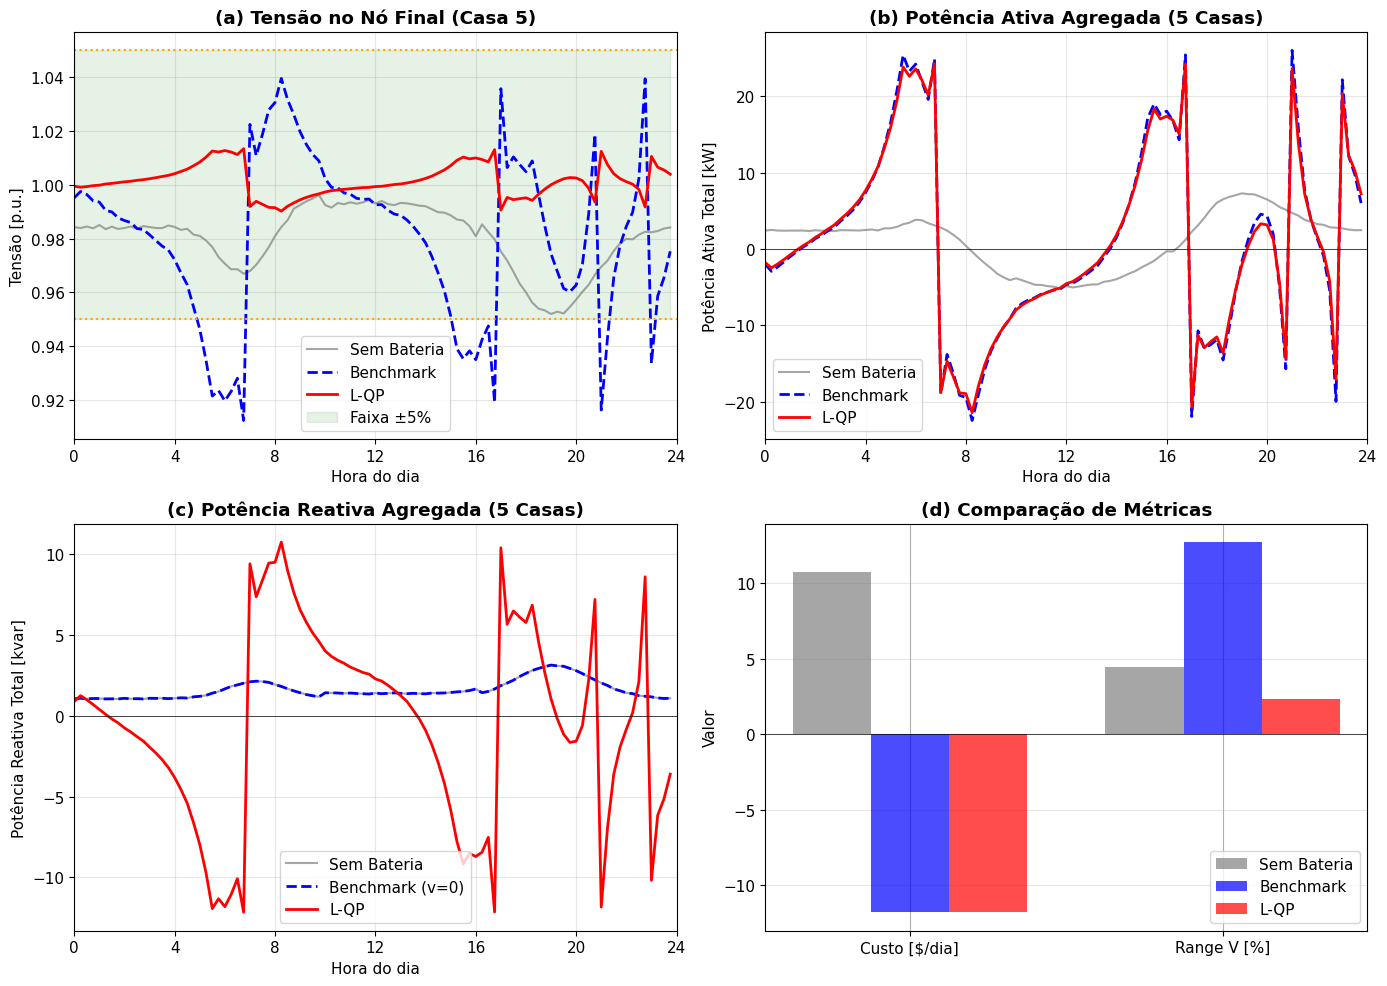


✓ Gráfico salvo: parte11_multiplas_casas.png
✓ PARTE 11.5 CONCLUÍDA!


In [23]:
"""
================================================================================
PARTE 11.5: GRÁFICOS COMPARATIVOS - MÚLTIPLAS CASAS
================================================================================
"""

print("="*70)
print("PARTE 11.6: GRÁFICOS COMPARATIVOS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ==============================================================================
# (a) Perfil de Tensão no Nó Final
# ==============================================================================
ax = axes[0, 0]
ax.plot(t, V_final_sem_bat, 'gray', lw=1.5, alpha=0.7, label='Sem Bateria')
ax.plot(t, V_final_bench, 'b--', lw=2, label='Benchmark')
ax.plot(t, V_final_lqp, 'r-', lw=2, label='L-QP')

ax.axhline(1.05, color='orange', ls=':', lw=1.5)
ax.axhline(0.95, color='orange', ls=':', lw=1.5)
ax.fill_between(t, 0.95, 1.05, alpha=0.1, color='green', label='Faixa ±5%')

ax.set_xlabel('Hora do dia')
ax.set_ylabel('Tensão [p.u.]')
ax.set_title('(a) Tensão no Nó Final (Casa 5)', fontweight='bold')
ax.set_xlim([0, 24])
ax.set_xticks(range(0, 25, 4))
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# ==============================================================================
# (b) Potência Ativa Total
# ==============================================================================
ax = axes[0, 1]

P_total_sem = np.sum(P_casas_sem_bat, axis=0)
P_total_bench = np.sum(P_casas_bench, axis=0)
P_total_lqp = np.sum(P_casas_lqp, axis=0)

ax.plot(t, P_total_sem, 'gray', lw=1.5, alpha=0.7, label='Sem Bateria')
ax.plot(t, P_total_bench, 'b--', lw=2, label='Benchmark')
ax.plot(t, P_total_lqp, 'r-', lw=2, label='L-QP')
ax.axhline(0, color='black', ls='-', lw=0.5)

ax.set_xlabel('Hora do dia')
ax.set_ylabel('Potência Ativa Total [kW]')
ax.set_title('(b) Potência Ativa Agregada (5 Casas)', fontweight='bold')
ax.set_xlim([0, 24])
ax.set_xticks(range(0, 25, 4))
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# ==============================================================================
# (c) Potência Reativa Total
# ==============================================================================
ax = axes[1, 0]

Q_total_sem = np.sum(Q_casas_sem_bat, axis=0)
Q_total_bench = np.sum(Q_casas_bench, axis=0)
Q_total_lqp = np.sum(Q_casas_lqp, axis=0)

ax.plot(t, Q_total_sem, 'gray', lw=1.5, alpha=0.7, label='Sem Bateria')
ax.plot(t, Q_total_bench, 'b--', lw=2, label='Benchmark (v=0)')
ax.plot(t, Q_total_lqp, 'r-', lw=2, label='L-QP')
ax.axhline(0, color='black', ls='-', lw=0.5)

ax.set_xlabel('Hora do dia')
ax.set_ylabel('Potência Reativa Total [kvar]')
ax.set_title('(c) Potência Reativa Agregada (5 Casas)', fontweight='bold')
ax.set_xlim([0, 24])
ax.set_xticks(range(0, 25, 4))
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# ==============================================================================
# (d) Comparação de Métricas
# ==============================================================================
ax = axes[1, 1]

metricas = ['Custo [$/dia]', 'Range V [%]']
x = np.arange(len(metricas))
width = 0.25

valores_sem = [custo_total_sem_bat, (V_final_sem_bat.max()-V_final_sem_bat.min())*100]
valores_bench = [sum(custos_bench), (V_final_bench.max()-V_final_bench.min())*100]
valores_lqp = [sum(custos_lqp), (V_final_lqp.max()-V_final_lqp.min())*100]

bars1 = ax.bar(x - width, valores_sem, width, label='Sem Bateria', color='gray', alpha=0.7)
bars2 = ax.bar(x, valores_bench, width, label='Benchmark', color='blue', alpha=0.7)
bars3 = ax.bar(x + width, valores_lqp, width, label='L-QP', color='red', alpha=0.7)

ax.set_ylabel('Valor')
ax.set_title('(d) Comparação de Métricas', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()
ax.axhline(0, color='black', lw=0.5)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('parte11_multiplas_casas.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Gráfico salvo: parte11_multiplas_casas.png")
print("="*70)
print("✓ PARTE 11.5 CONCLUÍDA!")
print("="*70)


In [25]:
print("="*70)
print("RESUMO FINAL - SIMULAÇÃO COM MÚLTIPLAS CASAS")
print("="*70)

print(f"""
                    CONCLUSÕES PRINCIPAIS

  🏠 SISTEMA SIMULADO:
     • 5 residências em alimentador radial
     • Cada casa com bateria 5kW/10kWh + PV

  🔴 PROBLEMA DO BENCHMARK (só P):
     • Range de tensão: {(V_final_bench.max()-V_final_bench.min())*100:.2f}% - PODE VIOLAR LIMITES!
     • V_min = {V_final_bench.min():.4f} p.u. | V_max = {V_final_bench.max():.4f} p.u.

  🟢 SOLUÇÃO L-QP (P + Q):
     • Range de tensão: {(V_final_lqp.max()-V_final_lqp.min())*100:.2f}% - EXCELENTE!
     • V_min = {V_final_lqp.min():.4f} p.u. | V_max = {V_final_lqp.max():.4f} p.u.
     • Mesmo custo: ${sum(custos_lqp):.2f}/dia

  💰 ECONOMIA TOTAL:
     • Por dia: ${custo_total_sem_bat - sum(custos_lqp):.2f}
     • Por ano: ${(custo_total_sem_bat - sum(custos_lqp))*365:.0f}

""")

print("="*70)
print("✅ PROJETO COMPLETO!")
print("="*70)

RESUMO FINAL - SIMULAÇÃO COM MÚLTIPLAS CASAS

                    CONCLUSÕES PRINCIPAIS                                    

  🏠 SISTEMA SIMULADO:
     • 5 residências em alimentador radial
     • Cada casa com bateria 5kW/10kWh + PV                                 

  🔴 PROBLEMA DO BENCHMARK (só P):                                          
     • Range de tensão: 12.72% - PODE VIOLAR LIMITES!                     
     • V_min = 0.9124 p.u. | V_max = 1.0396 p.u.                      

  🟢 SOLUÇÃO L-QP (P + Q):                                                   
     • Range de tensão: 2.32% - EXCELENTE!                            
     • V_min = 0.9902 p.u. | V_max = 1.0135 p.u.                      
     • Mesmo custo: $-11.78/dia                                        

  💰 ECONOMIA TOTAL:                                                                                            
     • Por dia: $22.50                                                    
     • Por ano: $8212         


PARTE 12: CONCLUSÃO FINAL E DOCUMENTAÇÃO

OTIMIZAÇÃO DE BATERIAS RESIDENCIAIS COM CONTROLE DE TENSÃO
(Formulação L-QP – um método matemático para decidir a melhor forma de operar a bateria)

RESUMO DO PROJETO

Este projeto desenvolveu uma otimização de controle para baterias residenciais. Ela decide automaticamente, ao longo do dia, quando carregar e descarregar a bateria e quanto ajudar a rede elétrica a manter a tensão estável. O objetivo é unir duas funções ao mesmo tempo:

ECONOMIZAR NA CONTA DE LUZ (Potência ativa – P)

Carrega a bateria quando a energia está mais barata.

Usa a bateria (descarrega) quando a energia está mais cara.

Resultado: reduz o custo de energia para o consumidor.

MELHORAR A QUALIDADE DA ENERGIA (Potência reativa – Q)

Ajuda a reduzir as oscilações de tensão (a “voltagem” da rede).

Essas oscilações aumentam com variações de consumo e com a geração solar (painéis fotovoltaicos).

Resultado: energia mais estável, com menor chance de problemas em equipamentos.

COMO FOI FEITO (METODOLOGIA)

Foi usado um modelo simplificado da rede elétrica para estimar como a tensão se comporta.

A otimização busca o melhor equilíbrio entre:
(a) economia (menor custo) e
(b) estabilidade da tensão (menor variação).

O dia foi analisado em 24 horas, dividido em intervalos de 15 minutos (96 decisões por dia).

O problema foi resolvido por um método de otimização matemática (QP) com a ferramenta CVXPY.

RESULTADOS PRINCIPAIS (O QUE MUDOU NA PRÁTICA)

Cenário 1: 1 casa

A economia obtida foi a mesma do método “benchmark” (que foca em economia).

A tensão ficou praticamente constante (variação próxima de zero).

Cenário 2: 5 casas (várias baterias ao mesmo tempo)

Sem bateria: a tensão variou em torno de ~5%.

Com benchmark (só economia): a tensão piorou e chegou a ~12,7%, pois as baterias tendem a agir juntas e criar picos.

Com L-QP (economia + controle de tensão): a economia foi mantida e a variação de tensão caiu para ~2,3%.

DESCOBERTAS IMPORTANTES (EM LINGUAGEM SIMPLES)

Otimizar só a economia pode piorar a tensão quando há muitas casas
Quando várias baterias carregam ou descarregam ao mesmo tempo, surgem “picos” que aumentam a variação da tensão.

É possível economizar e estabilizar a rede ao mesmo tempo
A potência ativa (P) cuida da economia e a potência reativa (Q) cuida da tensão, permitindo melhorar a qualidade da energia sem perder a economia.

A potência reativa ajuda na tensão sem aumentar o custo de energia
Esse ajuste melhora a rede principalmente pela qualidade, e não pelo consumo direto de energia.

Um ajuste pequeno já é suficiente (σ ≥ 0,005)
A partir desse valor, a otimização passa a atuar de forma eficaz para reduzir as variações de tensão.

APLICAÇÕES PRÁTICAS

Baterias residenciais e comerciais (ex.: Tesla Powerwall e similares).

Regiões com alta presença de energia solar em telhados.

Microrredes (condomínios, empresas, comunidades).

Agregadores de flexibilidade (VPPs) coordenando várias baterias.

Programas de resposta à demanda para reduzir picos e melhorar a rede.